# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [2]:
#!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

In [3]:
#!rm SUSY.csv

In [4]:
#!gunzip SUSY.csv.gz

In [5]:
ls -lh

total 2.5G
-rw-r--r-- 1 zendevs zendevs  33K Mar 20 23:27 Blackjack.py
-rw-r--r-- 1 zendevs zendevs  921 Feb  4 00:38 HelloWorld.ipynb
-rw-r--r-- 1 zendevs zendevs 287K Feb  9 21:26 Lab.2.ipynb
-rw-r--r-- 1 zendevs zendevs  62K Feb 15 19:27 Lab.3.ipynb
-rw-r--r-- 1 zendevs zendevs  56K Feb 15 18:26 Lab.3Solutions.ipynb
-rw-r--r-- 1 zendevs zendevs 103K Feb 21 03:07 Lab.4.Solution.ipynb
-rw-r--r-- 1 zendevs zendevs  32K Feb 20 23:58 Lab.4.ipynb
-rw-r--r-- 1 zendevs zendevs  64K Feb 27 22:11 Lab.5.Solutions.ipynb
-rw-r--r-- 1 zendevs zendevs  64K Feb 27 22:08 Lab.5.ipynb
-rw-r--r-- 1 zendevs zendevs 392K Mar 20 23:28 Lab.6.Solution.ipynb
-rw-r--r-- 1 zendevs zendevs 363K Mar 20 22:55 Lab.6.ipynb
-rw-r--r-- 1 zendevs zendevs 3.8M Apr  3 22:32 Lab.7.Solution.ipynb
-rw-r--r-- 1 zendevs zendevs 2.5M Mar 27 20:28 Lab.7.ipynb
-rw-r--r-- 1 zendevs zendevs 200K Mar 20 19:23 Lab_6_complete.ipynb
-rw-r--r-- 1 zendevs zendevs 299K Mar  6 17:37 Lecture.11.ipynb
-rw-r--r-- 1 zendevs zendevs 117K Mar 

The data is provided as a comma separated file.

The above file directory is my standard python work env, SUSY.csv was downloaded correctly and is quite hefty at ~2.3G

In [6]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [7]:
!ls -lh

total 2.5G
-rw-r--r-- 1 zendevs zendevs  33K Mar 20 23:27 Blackjack.py
-rw-r--r-- 1 zendevs zendevs  921 Feb  4 00:38 HelloWorld.ipynb
-rw-r--r-- 1 zendevs zendevs 287K Feb  9 21:26 Lab.2.ipynb
-rw-r--r-- 1 zendevs zendevs  62K Feb 15 19:27 Lab.3.ipynb
-rw-r--r-- 1 zendevs zendevs  56K Feb 15 18:26 Lab.3Solutions.ipynb
-rw-r--r-- 1 zendevs zendevs 103K Feb 21 03:07 Lab.4.Solution.ipynb
-rw-r--r-- 1 zendevs zendevs  32K Feb 20 23:58 Lab.4.ipynb
-rw-r--r-- 1 zendevs zendevs  64K Feb 27 22:11 Lab.5.Solutions.ipynb
-rw-r--r-- 1 zendevs zendevs  64K Feb 27 22:08 Lab.5.ipynb
-rw-r--r-- 1 zendevs zendevs 392K Mar 20 23:28 Lab.6.Solution.ipynb
-rw-r--r-- 1 zendevs zendevs 363K Mar 20 22:55 Lab.6.ipynb
-rw-r--r-- 1 zendevs zendevs 3.8M Apr  3 22:32 Lab.7.Solution.ipynb
-rw-r--r-- 1 zendevs zendevs 2.5M Mar 27 20:28 Lab.7.ipynb
-rw-r--r-- 1 zendevs zendevs 200K Mar 20 19:23 Lab_6_complete.ipynb
-rw-r--r-- 1 zendevs zendevs 299K Mar  6 17:37 Lecture.11.ipynb
-rw-r--r-- 1 zendevs zendevs 117K Mar 

We see that we have 5 million datapoints.

As noted before, SUSY stands at around 2.3 Gigabytes

In [8]:
!wc -l SUSY.csv

5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [9]:
!head -500000 SUSY.csv > SUSY-small.csv

In [10]:
ls -lh

total 2.5G
-rw-r--r-- 1 zendevs zendevs  33K Mar 20 23:27 Blackjack.py
-rw-r--r-- 1 zendevs zendevs  921 Feb  4 00:38 HelloWorld.ipynb
-rw-r--r-- 1 zendevs zendevs 287K Feb  9 21:26 Lab.2.ipynb
-rw-r--r-- 1 zendevs zendevs  62K Feb 15 19:27 Lab.3.ipynb
-rw-r--r-- 1 zendevs zendevs  56K Feb 15 18:26 Lab.3Solutions.ipynb
-rw-r--r-- 1 zendevs zendevs 103K Feb 21 03:07 Lab.4.Solution.ipynb
-rw-r--r-- 1 zendevs zendevs  32K Feb 20 23:58 Lab.4.ipynb
-rw-r--r-- 1 zendevs zendevs  64K Feb 27 22:11 Lab.5.Solutions.ipynb
-rw-r--r-- 1 zendevs zendevs  64K Feb 27 22:08 Lab.5.ipynb
-rw-r--r-- 1 zendevs zendevs 392K Mar 20 23:28 Lab.6.Solution.ipynb
-rw-r--r-- 1 zendevs zendevs 363K Mar 20 22:55 Lab.6.ipynb
-rw-r--r-- 1 zendevs zendevs 3.8M Apr  3 22:32 Lab.7.Solution.ipynb
-rw-r--r-- 1 zendevs zendevs 2.5M Mar 27 20:28 Lab.7.ipynb
-rw-r--r-- 1 zendevs zendevs 200K Mar 20 19:23 Lab_6_complete.ipynb
-rw-r--r-- 1 zendevs zendevs 299K Mar  6 17:37 Lecture.11.ipynb
-rw-r--r-- 1 zendevs zendevs 117K Mar 

Though cluttered, you can observe the SUSY-small.csv file has been created above pycahce

In [11]:
! wc -l SUSY-small.csv

500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [12]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [13]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [14]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [15]:
FeatureNames

['dPhi_r_b',
 'R',
 'MET_rel',
 'cos_theta_r1',
 'MT2',
 'S_R',
 'axial_MET',
 'M_TR_2',
 'M_Delta_R',
 'M_R']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [17]:
filename = "SUSY.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [18]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [19]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


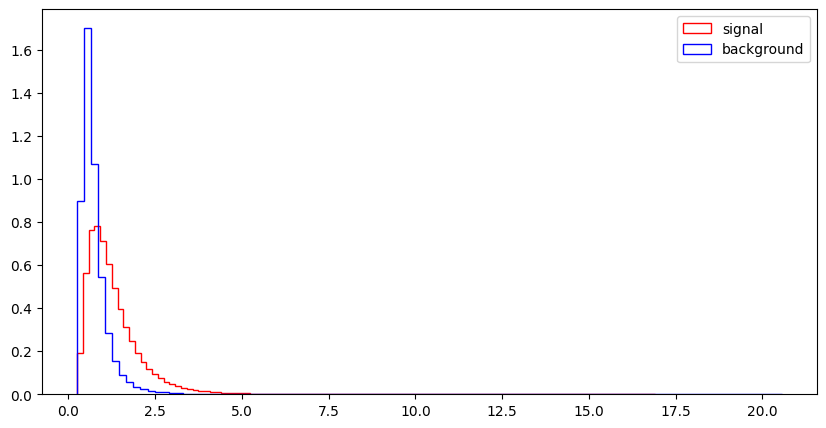

l_1_eta


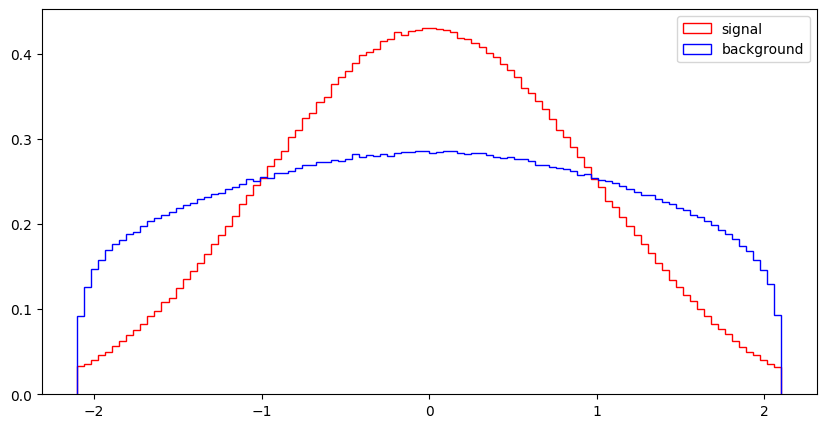

l_1_phi


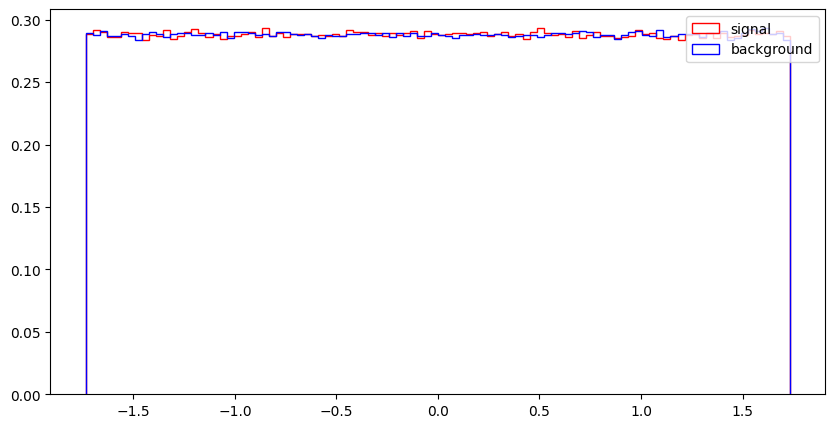

l_2_pT


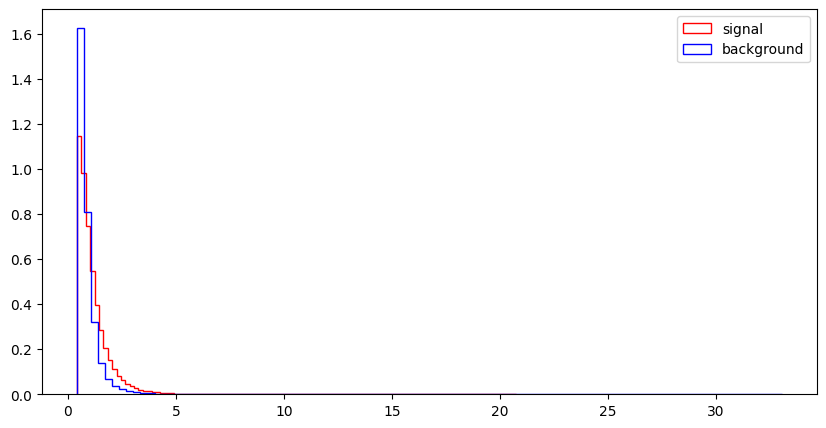

l_2_eta


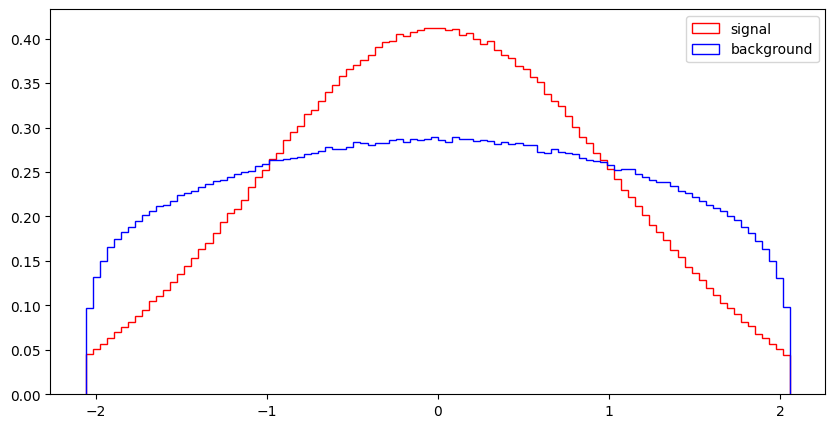

l_2_phi


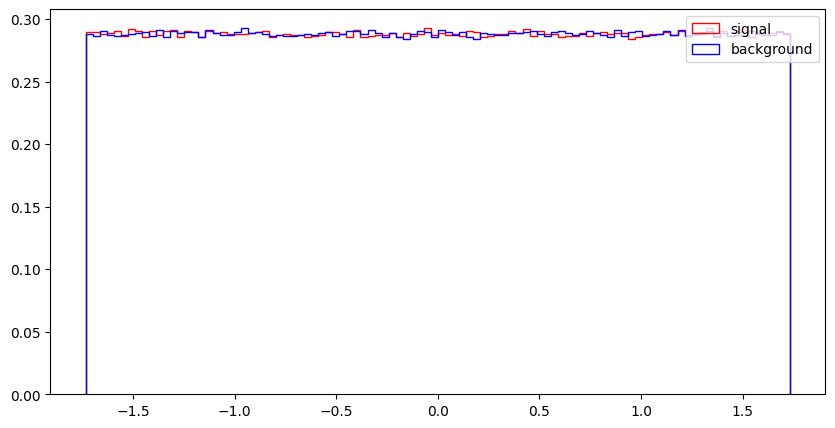

MET


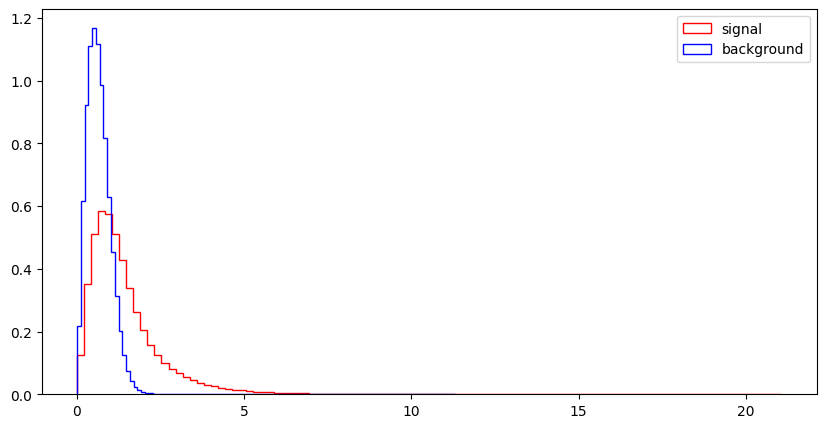

MET_phi


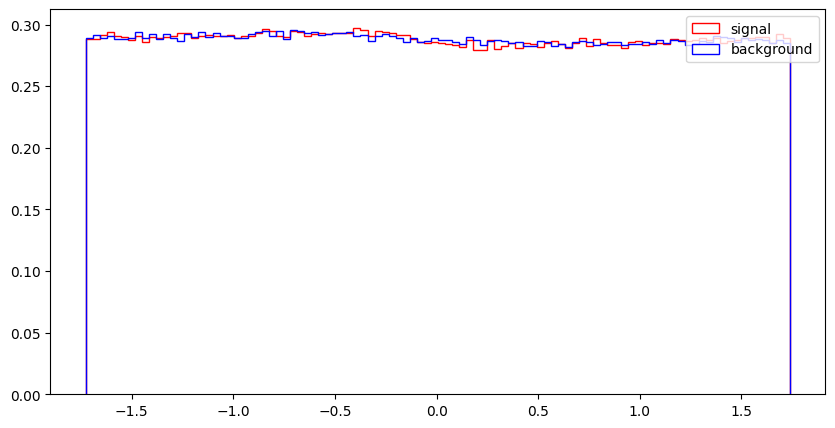

MET_rel


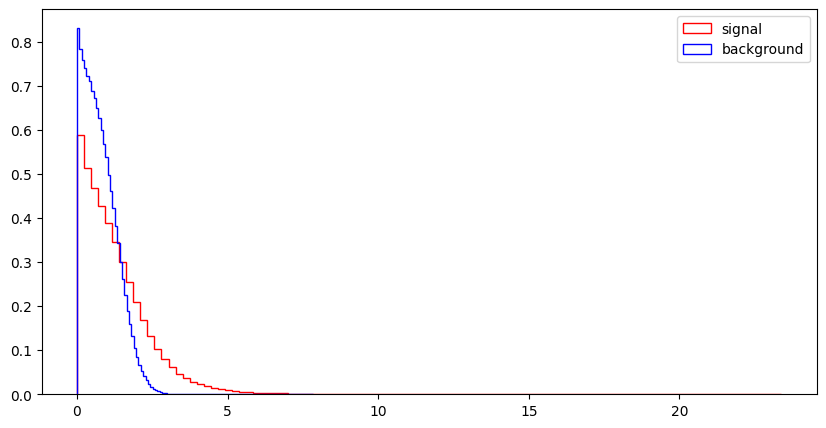

axial_MET


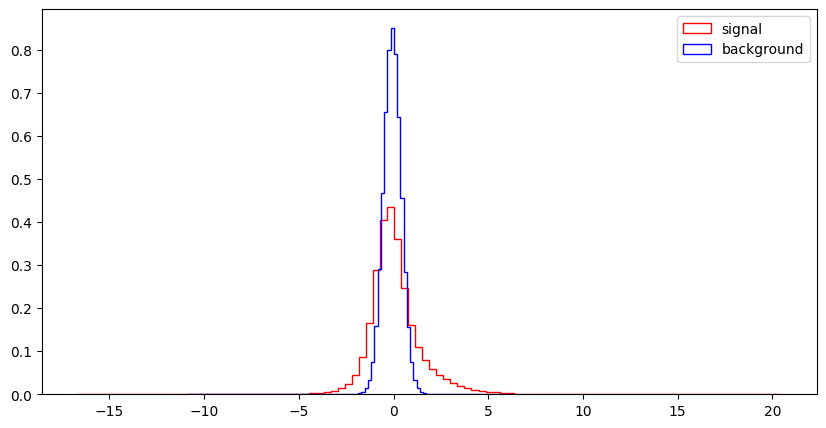

M_R


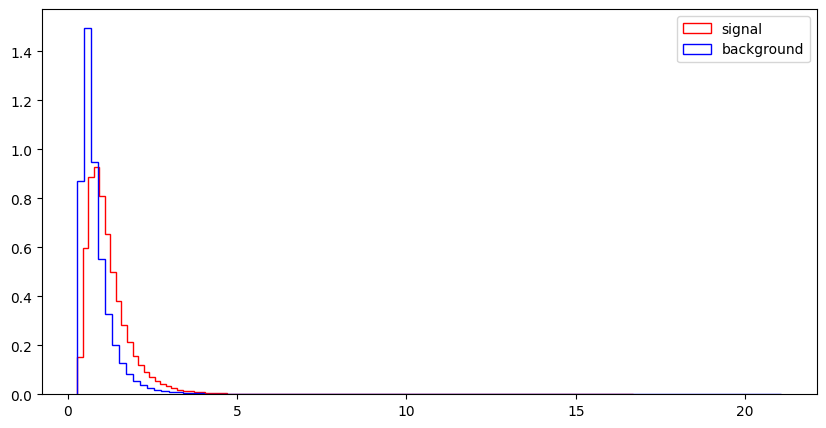

M_TR_2


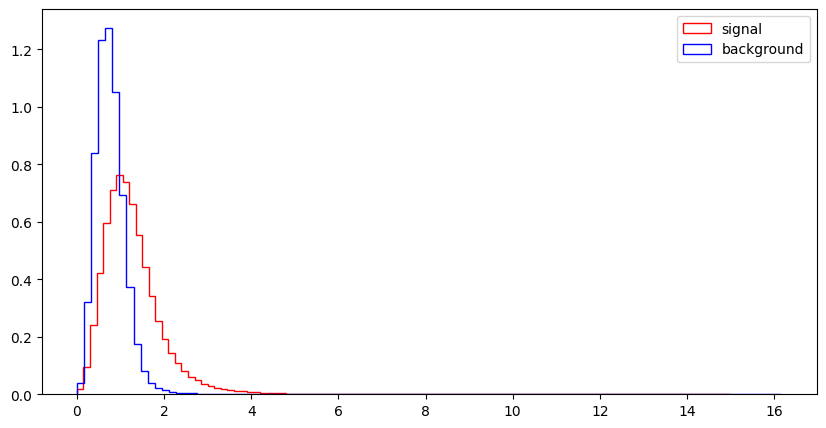

R


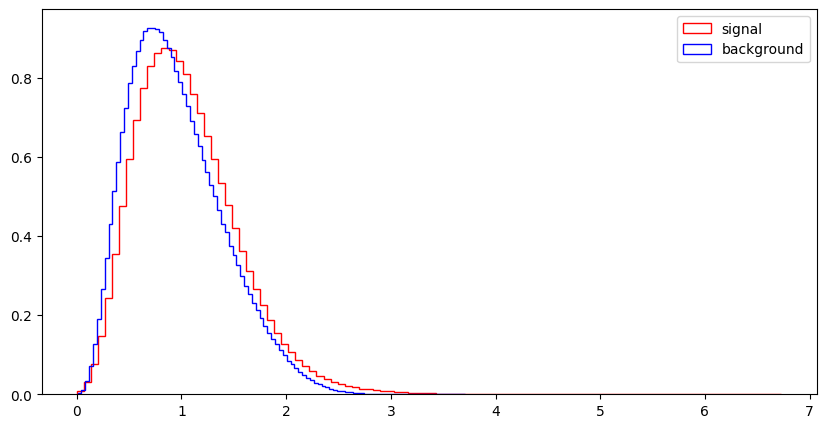

MT2


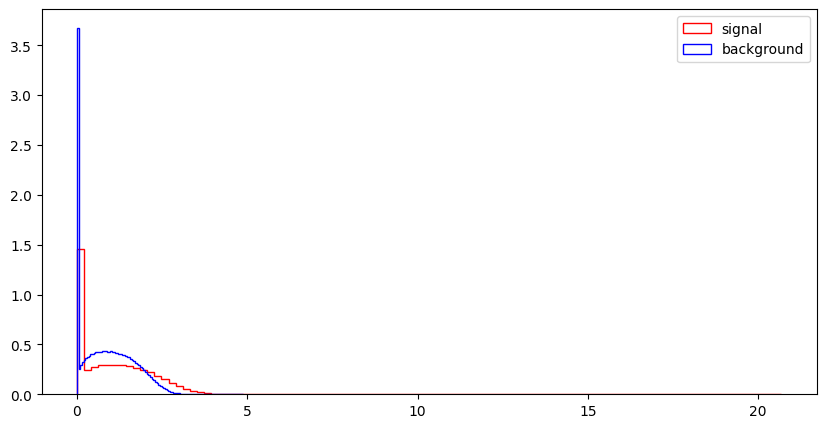

S_R


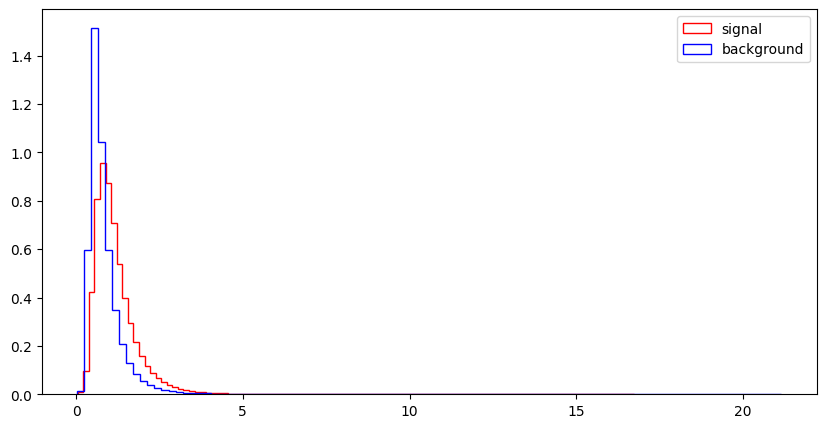

M_Delta_R


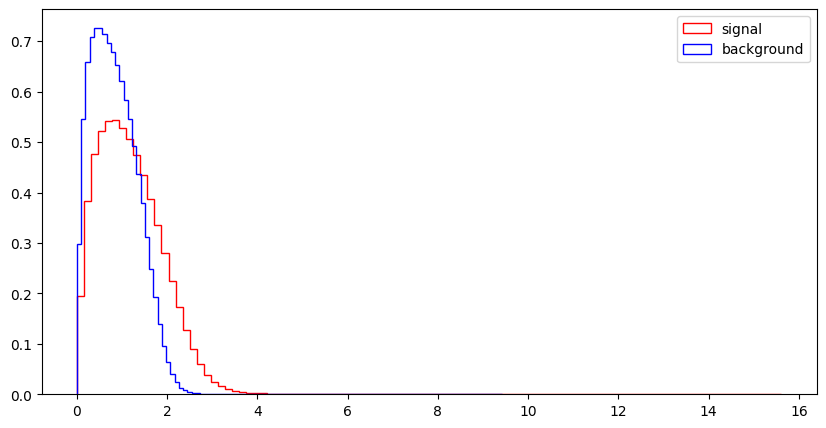

dPhi_r_b


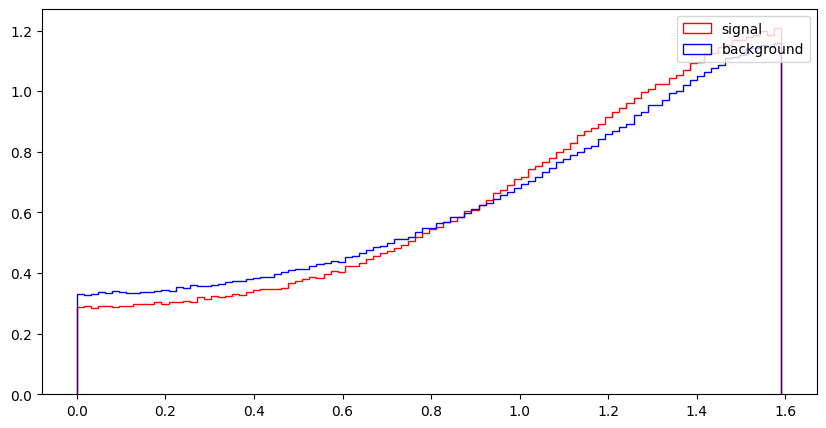

cos_theta_r1


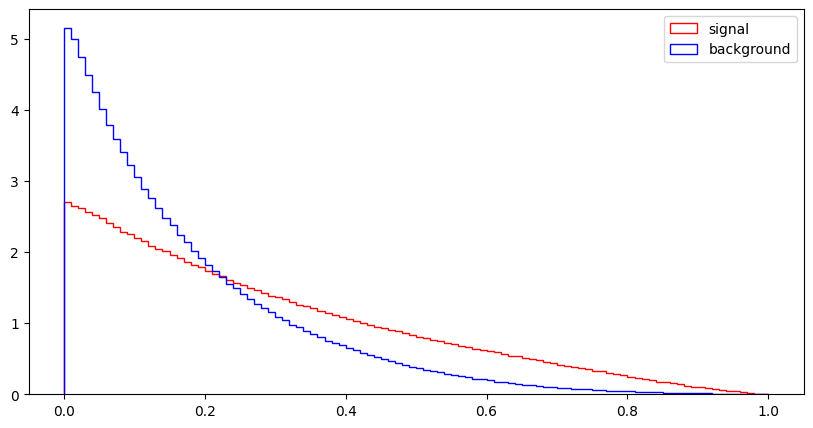

In [20]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

The paper has charts very similar to the ones shown at the end of exercise 2, essentially we are charting everything within VarNames. As described prior, we will be using the SUSY-small.csv file for operations here on out. In figure 5, it has data that is not lepton/n jets/etc so I take it that we are only seeking to format it in the same manner. Figure 6 features data points very similarly to what is seen above. Below, we will have the visual representation that will mimic what is seen in figures 5 and 6.

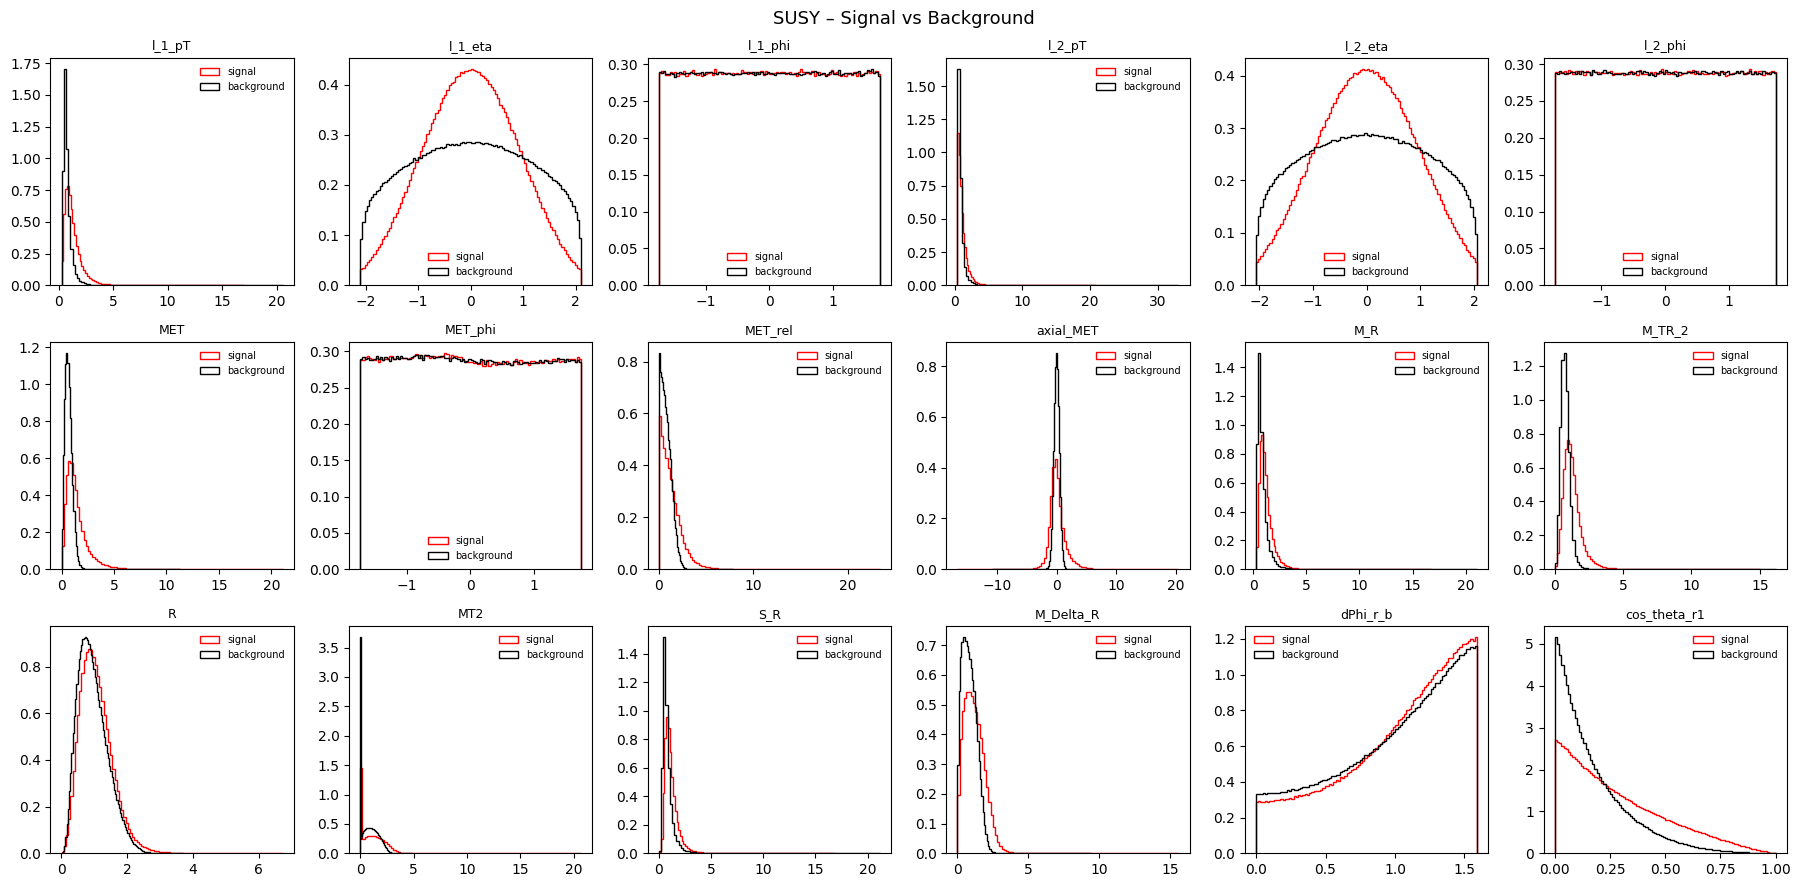

In [21]:
# I omitted this one and left it since it was already made, the code cell below is the final submission, this was just the first iteration

import numpy as np
import matplotlib.pyplot as plt

# Still working with the VarNames[1:] library like the one before

n_vars = len(VarNames[1:])
ncols = 6
nrows = int(np.ceil(n_vars / ncols))  # 3 rows of 6

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 9))
axes = axes.flatten()

for ax, var in zip(axes, VarNames[1:]):
    ax.hist(np.array(df_sig[var]), bins=100, histtype="step",
            color="red",   label="signal",     density=True, stacked=True)
    ax.hist(np.array(df_bkg[var]), bins=100, histtype="step",
            color="black", label="background", density=True, stacked=True)
    ax.set_title(var, fontsize=9)
    ax.legend(fontsize=7, frameon=False)

# Hide any leftover empty axes
for ax in axes[n_vars:]:
    ax.set_visible(False)

fig.suptitle("SUSY – Signal vs Background", fontsize=13)
fig.tight_layout()
plt.show()

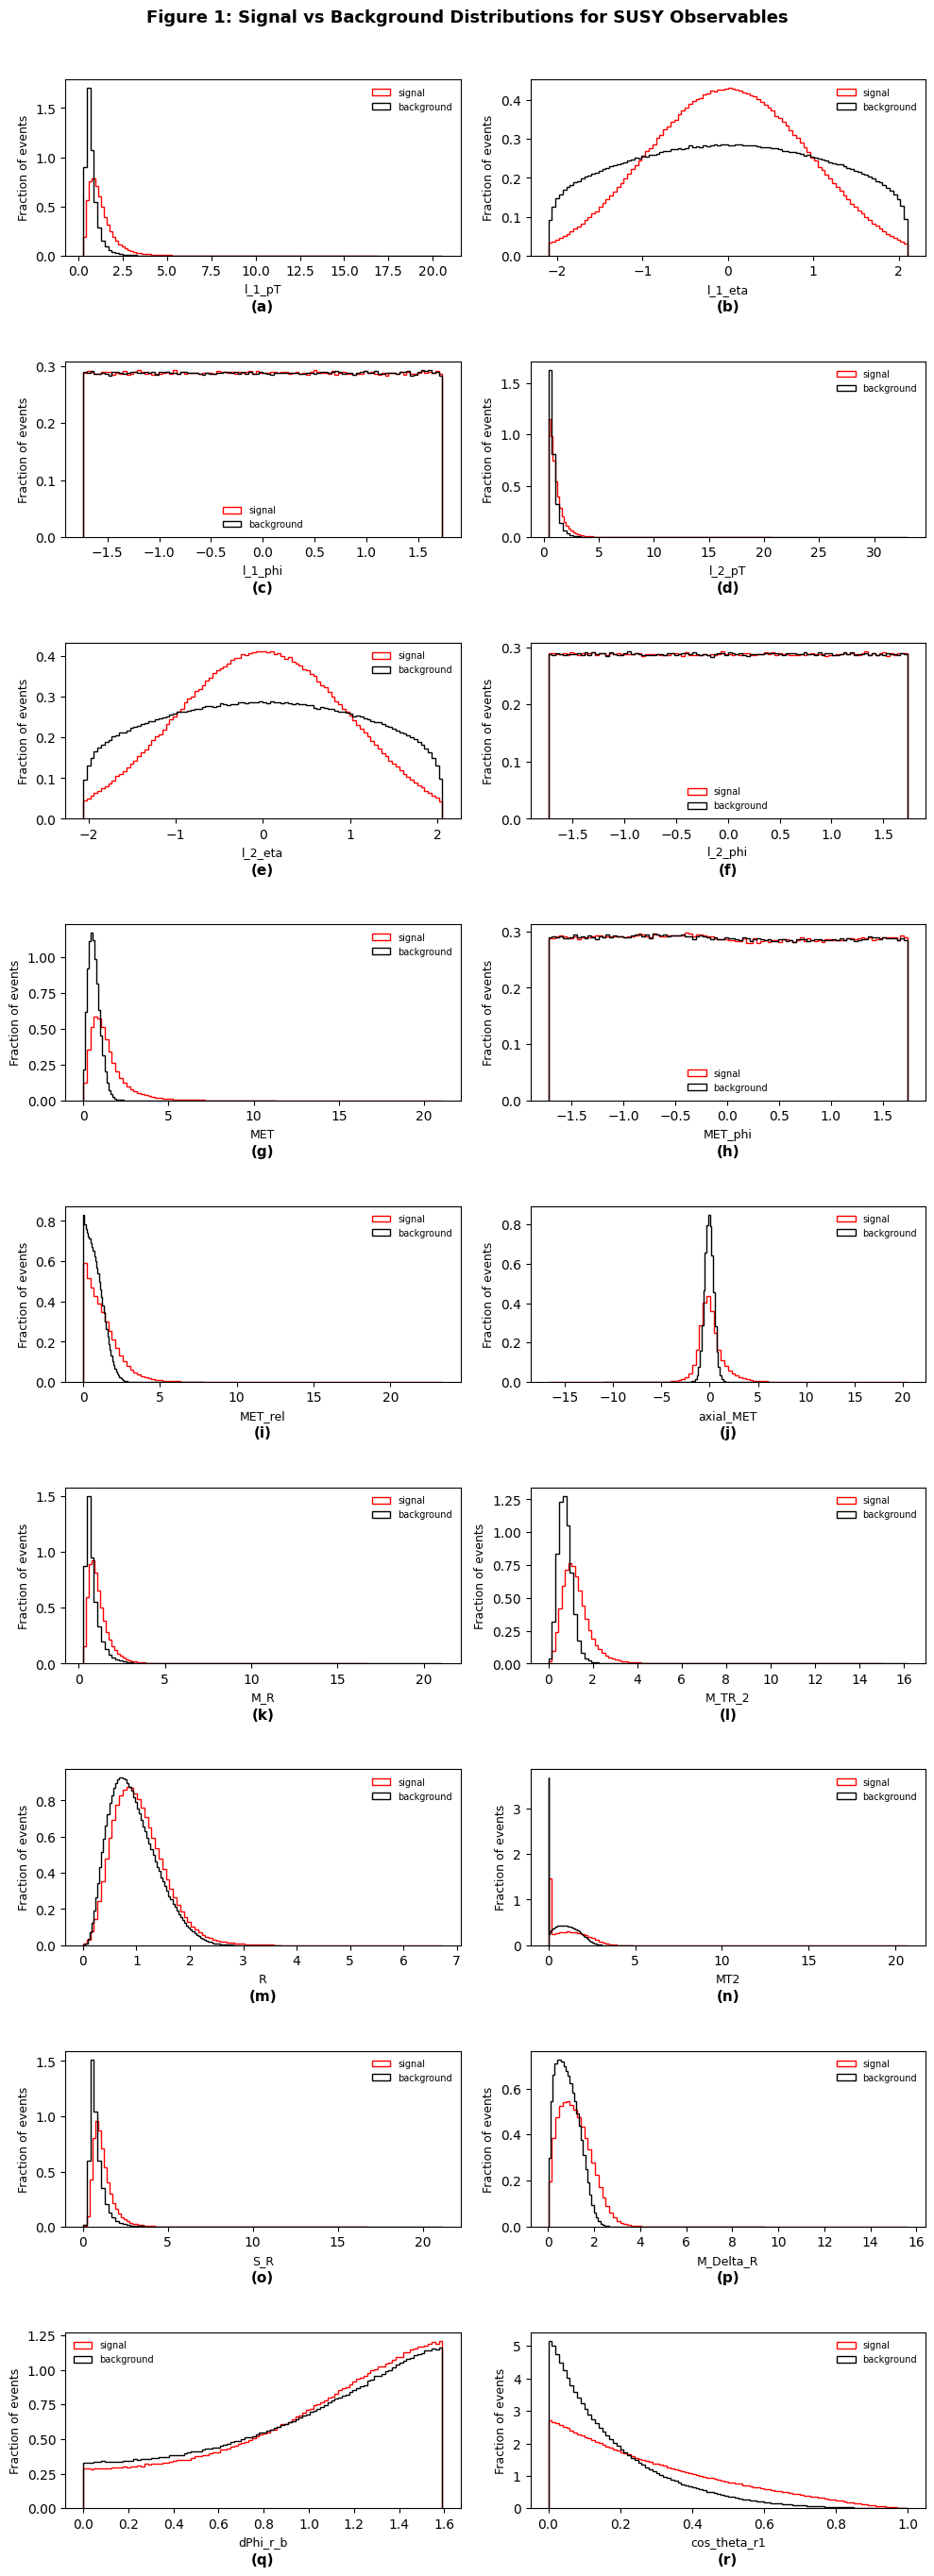

Key:
  (a)  l_1_pT
  (b)  l_1_eta
  (c)  l_1_phi
  (d)  l_2_pT
  (e)  l_2_eta
  (f)  l_2_phi
  (g)  MET
  (h)  MET_phi
  (i)  MET_rel
  (j)  axial_MET
  (k)  M_R
  (l)  M_TR_2
  (m)  R
  (n)  MT2
  (o)  S_R
  (p)  M_Delta_R
  (q)  dPhi_r_b
  (r)  cos_theta_r1

In context, this would be included as a figure and a greater text
can correspond with specific labels using (a), (b), and so on


In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Slice off the 'signal' label at index 0, leaving only the 18 observable names
# We do not want to list Signal as an individual hist
vars_list = VarNames[1:]

# Set 2 histograms per row as seen in figures
ncols = 2

# Calculate the number of rows needed to fit all variables at 2 per row
nrows = int(np.ceil(len(vars_list) / ncols))

# Generate alphabetical labels (a), (b), ... , (r) — one per variable
# Uses chr() to convert integers to characters: chr(97) = 'a', chr(98) = 'b', etc.
# These replace titles and correspond to the printed key below
labels = [f"({chr(97 + i)})" for i in range(len(vars_list))]

# Create the figure and grid of subplots
# figsize scales height dynamically so rows don't get cramped as nrows grows
fig, axes = plt.subplots(nrows, ncols, figsize=(10, nrows * 3))

# Flatten the 2D array of axes into 1D so we can iterate over it easily
axes = axes.flatten()

# Loop over each variable, its corresponding subplot, and its letter label
for ax, var, label in zip(axes, vars_list, labels):

    # Plot normalised signal distribution in red
    ax.hist(np.array(df_sig[var]), bins=100, histtype="step",
            color="red", label="signal", density=True)

    # Plot normalised background distribution in black
    ax.hist(np.array(df_bkg[var]), bins=100, histtype="step",
            color="black", label="background", density=True)

    # Set the x-axis label to the variable name so each panel is self-describing
    ax.set_xlabel(var, fontsize=9)

    # Set the y-axis label to describe the normalised histogram content
    ax.set_ylabel("Fraction of events", fontsize=9)

    # Place the letter label centered below the x-axis using set_xlabel is not ideal,
    # so we use ax.text with axis coordinates (0.5, 0) to anchor it just below the panel
    ax.text(0.5, -0.25, label, transform=ax.transAxes,
            fontsize=11, fontweight="bold", ha="center", va="top")

    # Add a small legend to each panel to identify signal vs background curves
    ax.legend(fontsize=7, frameon=False)

# If the total number of variables is odd, the last subplot will be empty
# Hide it so it doesn't appear as a blank panel in the figure
for ax in axes[len(vars_list):]:
    ax.set_visible(False)

# Subtitle addition to be more in-line with figure 5 and 6
fig.suptitle("Figure 1: Signal vs Background Distributions for SUSY Observables",
             fontsize=13, fontweight="bold", y=1.01)

# Increase bottom padding so the letter labels below each panel are not clipped
fig.tight_layout()
plt.subplots_adjust(hspace=0.6)
plt.show()

# Print the key that maps each letter label back to its variable name
# This replaces the per-panel titles and allows a cleaner figure layout
# Matches the figures
print("Key:")
for label, var in zip(labels, vars_list):
    print(f"  {label}  {var}")
print("\nIn context, this would be included as a figure and a greater text")
print("can correspond with specific labels using (a), (b), and so on")

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

**For personal clarification:**

Low-level (raw) observables — RawNames — are the direct measurements that come straight out of the detector. Things like the momentum (pT), angles (eta, phi), and missing energy (MET) of the detected particles. These are the raw numbers the experiment actually measures — no extra calculation involved.

High-level (derived) features — FeatureNames — are quantities that physicists have manually engineered by combining the raw observables using their knowledge of the physics. For example, M_R, MT2, and S_R are composite variables constructed specifically because they are theoretically expected to be good at distinguishing SUSY signal events from background. They take more domain knowledge to construct but tend to carry more discriminating power.

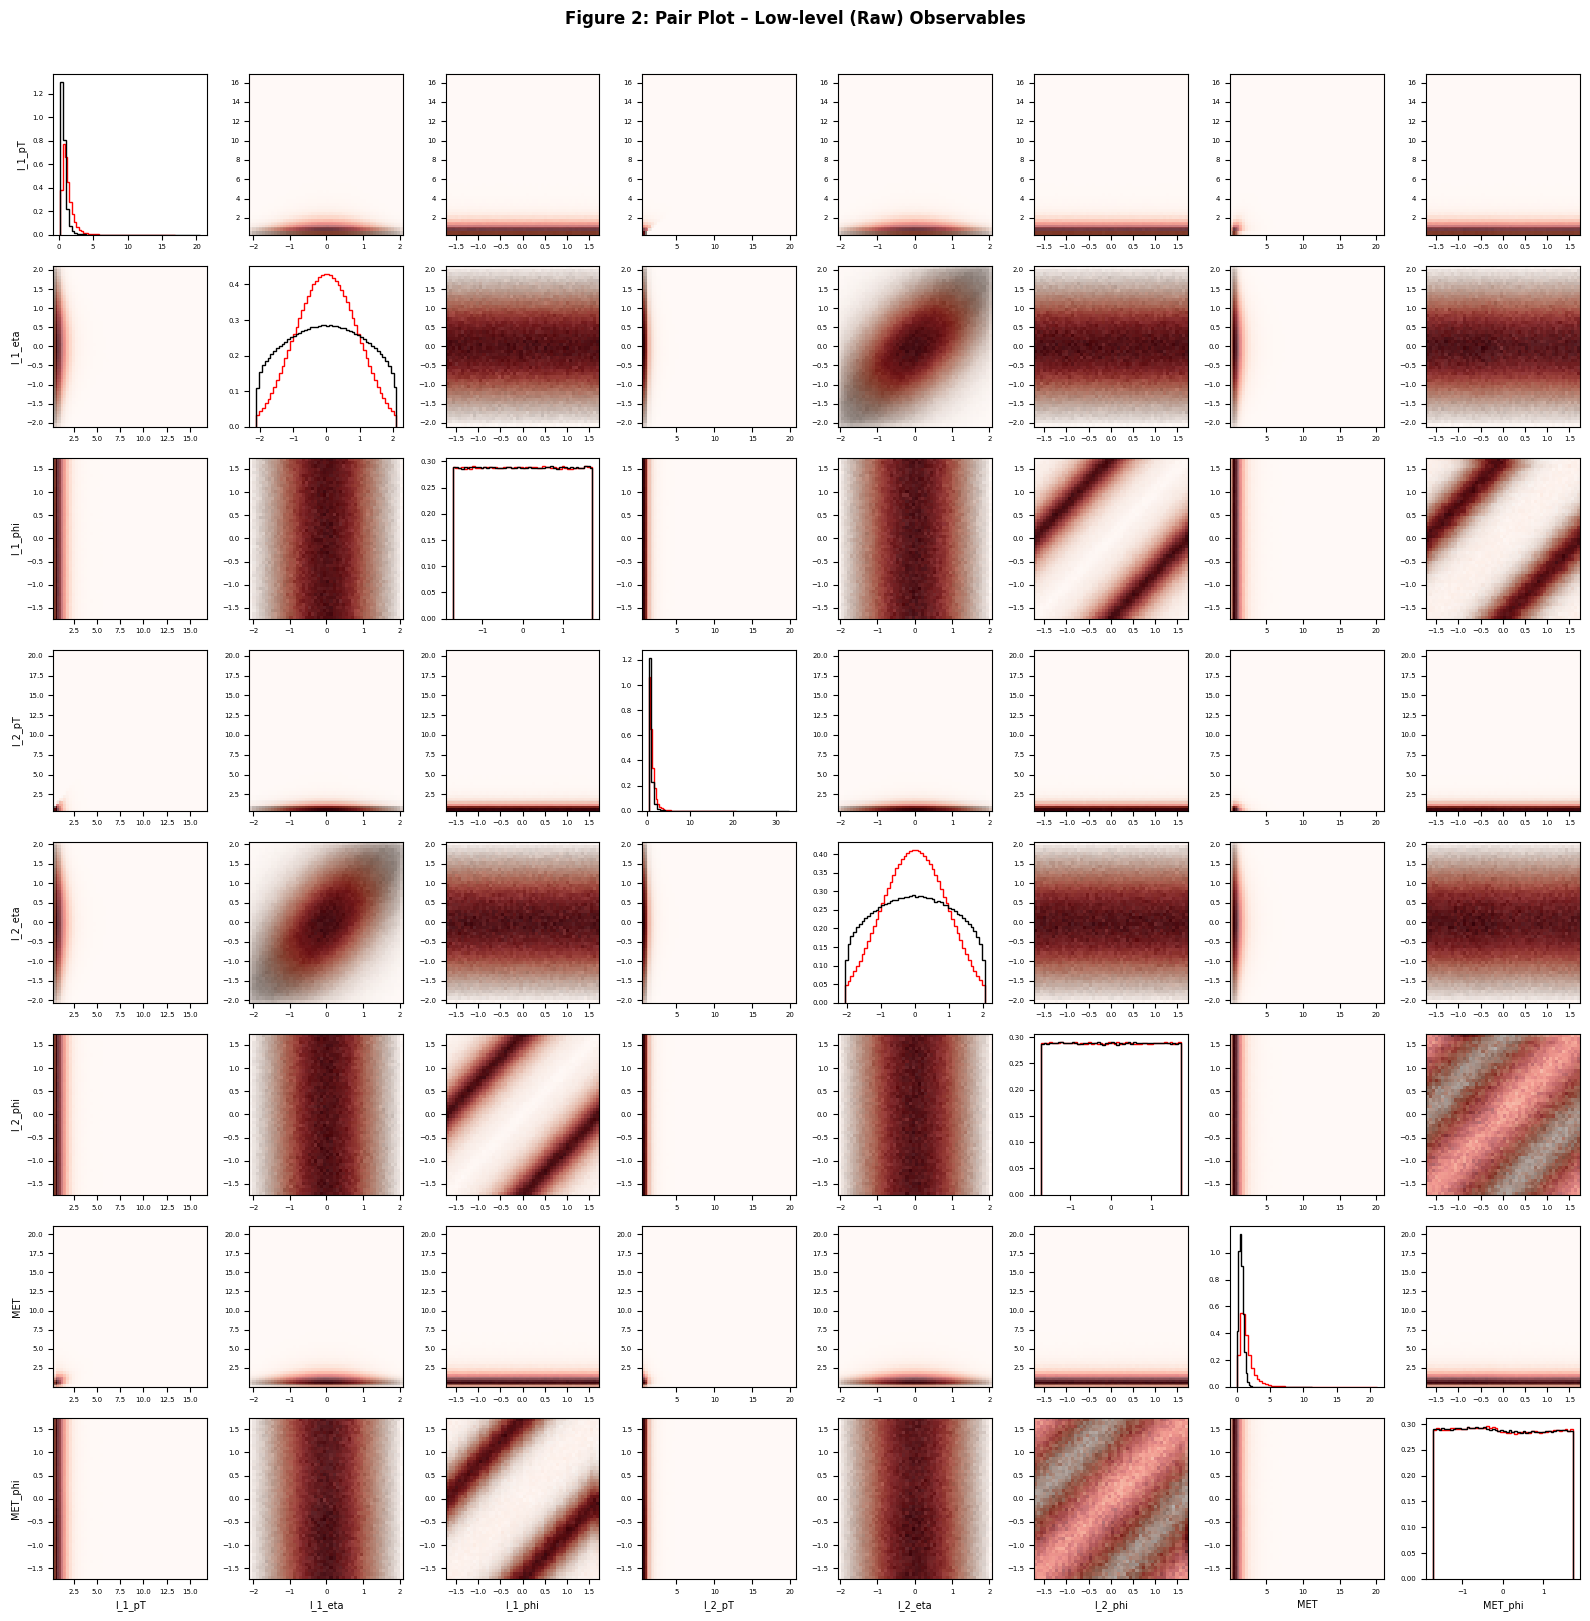

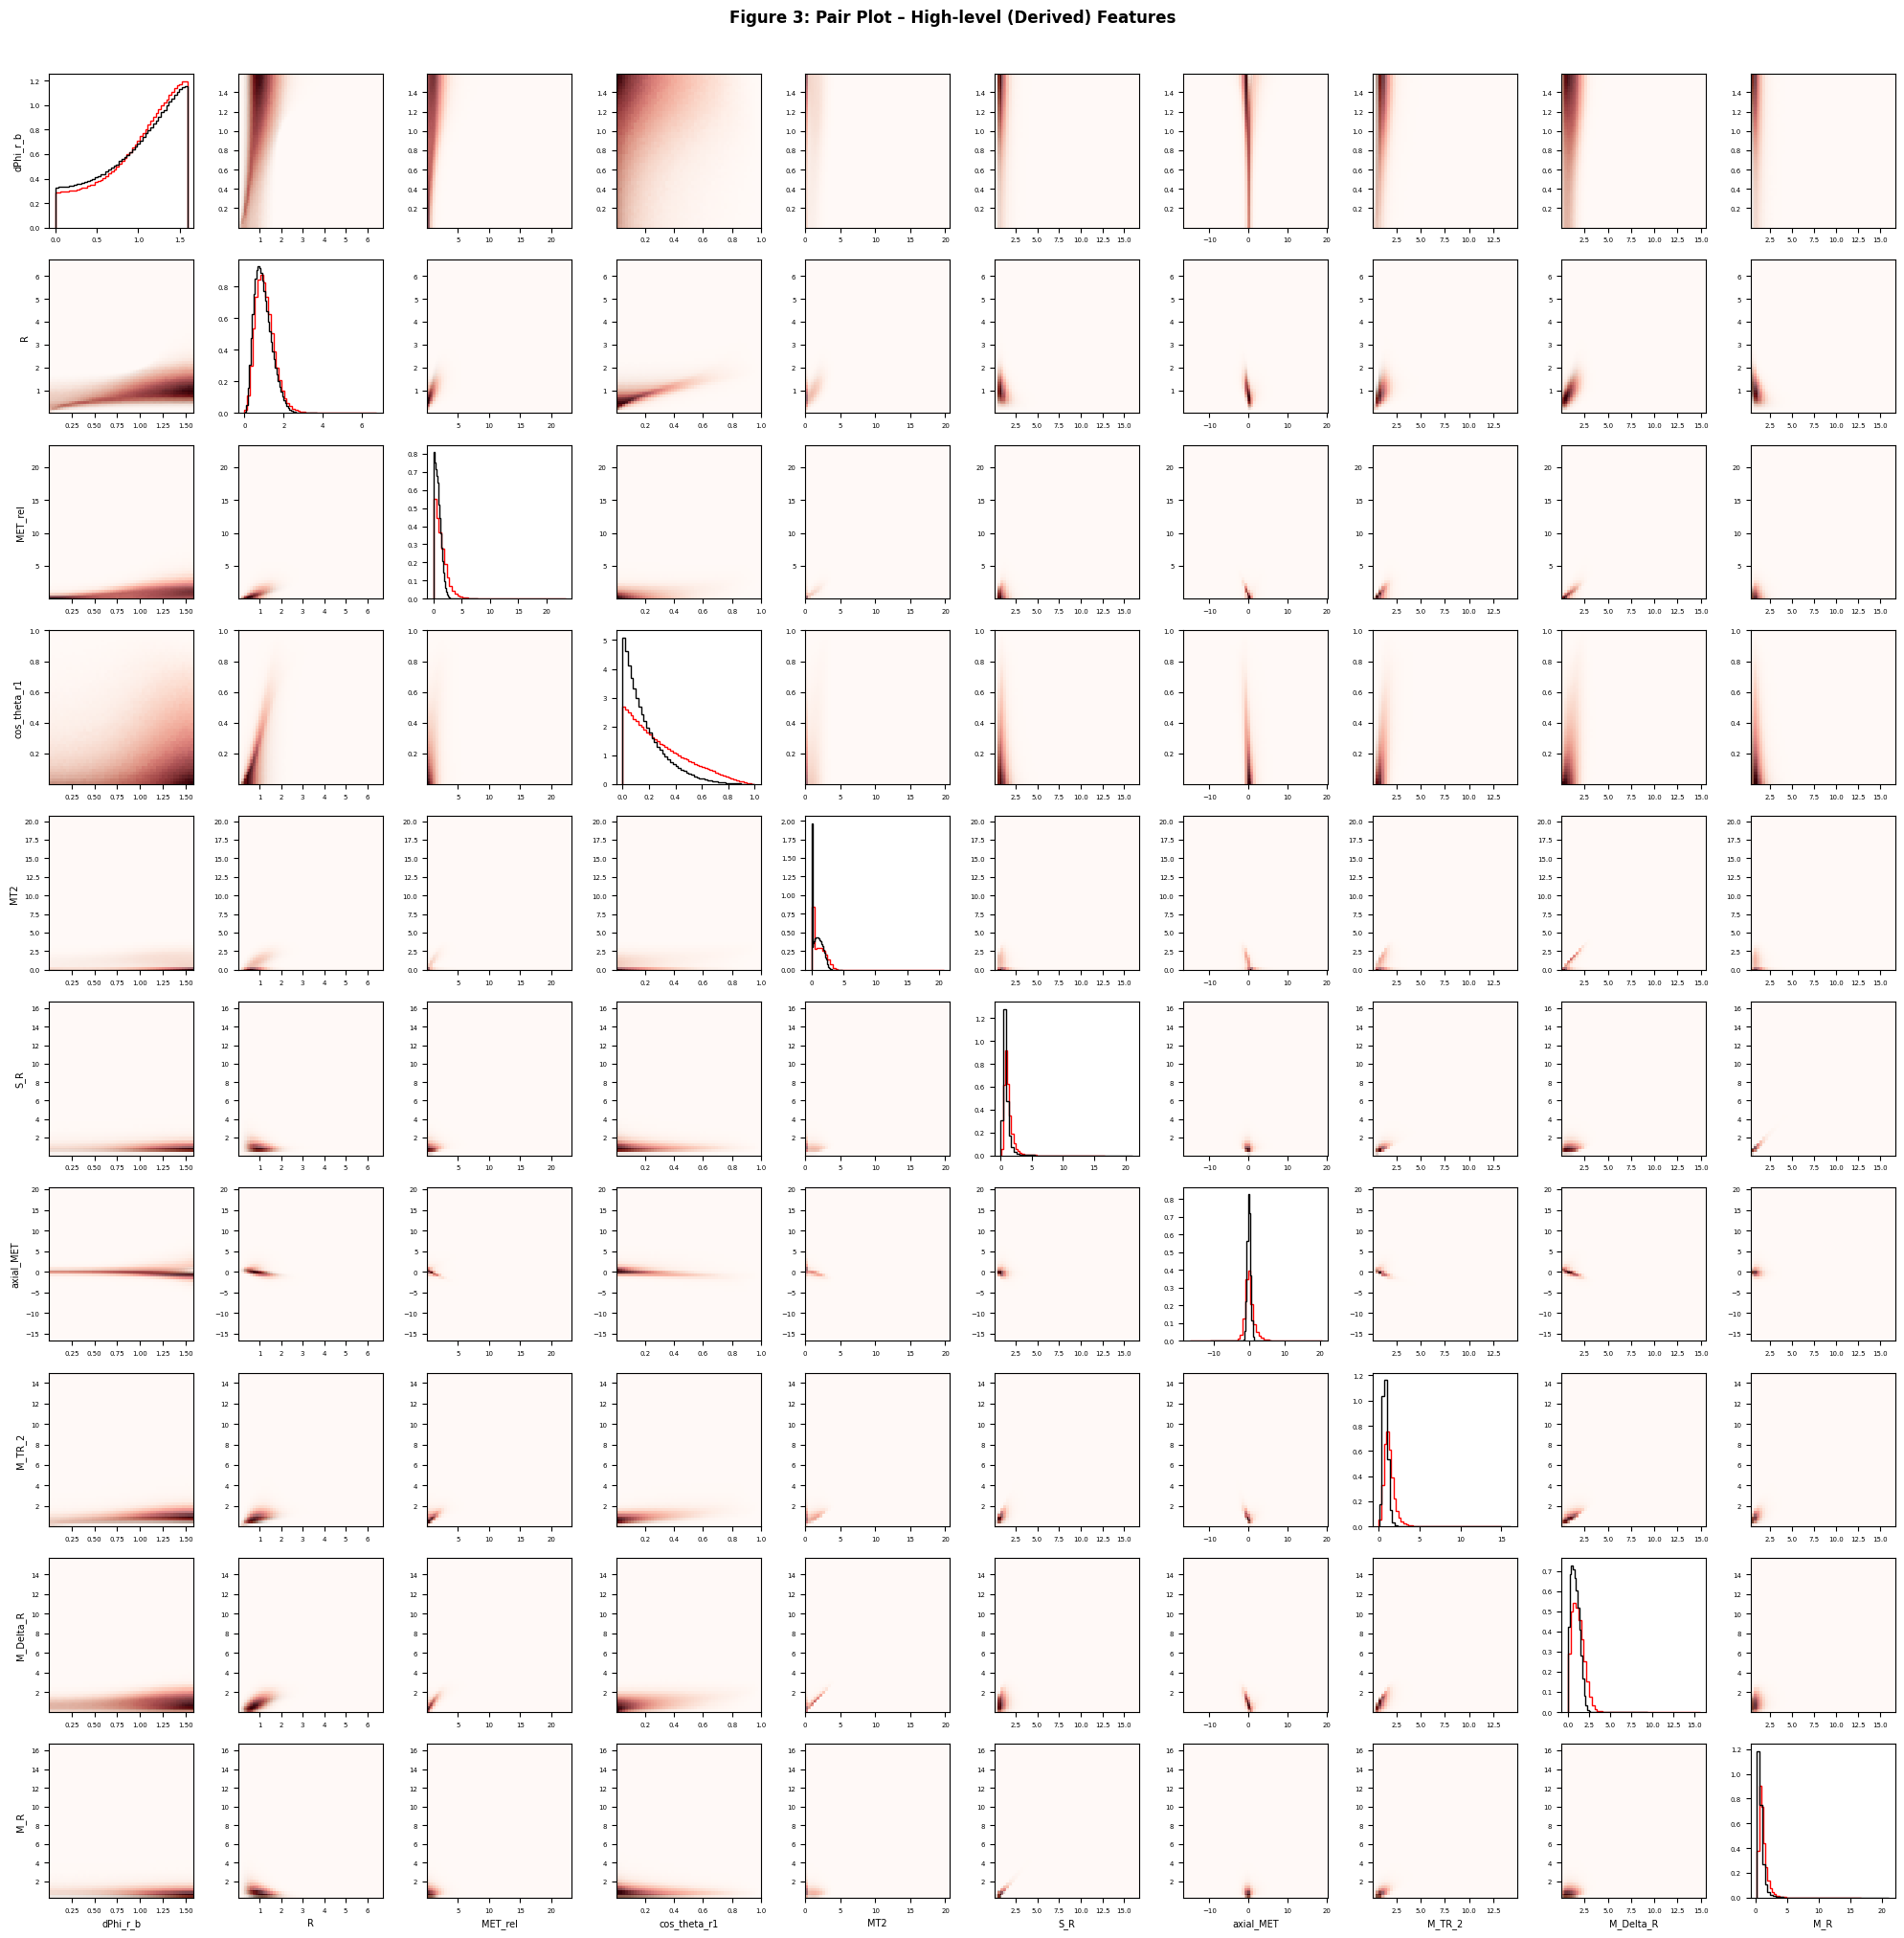

In [23]:
# Part A
# Pair plot production - high and low level - without using seaborn

import numpy as np
import matplotlib.pyplot as plt

def pair_plot(df_sig, df_bkg, var_list, title="Pair Plot"):
    # Creates pair plot comparing signal & background dist for every combination
    # of variables in its var_list

    # Along the diagonal, 1 dimensional hist show marginal dist of each var individually.
    # Off diagonal, 2 dim histograms show how pairs of variables relate

    # Parameters:
    #     df_sig   : DataFrame containing only signal events (signal == 1)
    #     df_bkg   : DataFrame containing only background events (signal == 0)
    #     var_list : list of variable name strings to include in the grid
    #     title    : overall figure title displayed above the grid

    # Number of variables determines the grid dimensions (n x n)
    n = len(var_list)

    # Create the n x n subplot grid — each cell is one variable pair
    fig, axes = plt.subplots(n, n, figsize=(n * 2, n * 2))

    # Loop over every combination of variables for the y and x axes
    for i, var_y in enumerate(var_list):
        for j, var_x in enumerate(var_list):

            ax = axes[i, j]

            if i == j:
                # Diagonal paenls
                # When both axes represent the same variable, plot 1D histograms to show the marginal
                # distribution for signal and background, basically what has been observed before
                ax.hist(df_sig[var_x], bins=50, histtype="step",
                        color="red",   density=True)
                ax.hist(df_bkg[var_x], bins=50, histtype="step",
                        color="black", density=True)

            else:
                # Off-diagonal panels
                # Plot 2D histograms for each pair of variables. hist2d is used instead of scatter for performance — scatter
                # renders one point per event (up to 500k), whereas hist2d bins the data into a fixed grid first, making it much faster.
                # Background is plotted first in greyscale, signal overlaid in red with transparency so both are visible where they overlap.
                ax.hist2d(df_bkg[var_x], df_bkg[var_y], bins=50,
                          cmap="Greys", density=True)
                ax.hist2d(df_sig[var_x], df_sig[var_y], bins=50,
                          cmap="Reds",  density=True, alpha=0.5)

            # Axis labels
            # Only label the bottom row (x) and left column (y) to avoid
            # cluttering the interior of the grid with repeated labels
            if i == n - 1:
                ax.set_xlabel(var_x, fontsize=7)
            if j == 0:
                ax.set_ylabel(var_y, fontsize=7)

            # Shrink tick labels so they fit within the small panel size
            ax.tick_params(labelsize=5)

    # Add an overall title above the grid, like the first figure
    fig.suptitle(title, fontsize=12, fontweight="bold", y=1.01)

    # Tighten spacing between panels so labels and plots don't overlap
    fig.tight_layout()
    plt.show()


# Test - Generate pair plots for low-level and high-level variables

# Low-level raw observables — direct detector measurements (8 x 8 grid)
# Expect relatively poor signal/background separation in most panels
pair_plot(df_sig, df_bkg, RawNames,
          title="Figure 2: Pair Plot – Low-level (Raw) Observables")

# High-level derived features — physicist-engineered composite variables (10 x 10 grid)
# Expect stronger separation, particularly in M_R, MT2, S_R, and M_TR_2
pair_plot(df_sig, df_bkg, FeatureNames,
          title="Figure 3: Pair Plot – High-level (Derived) Features")

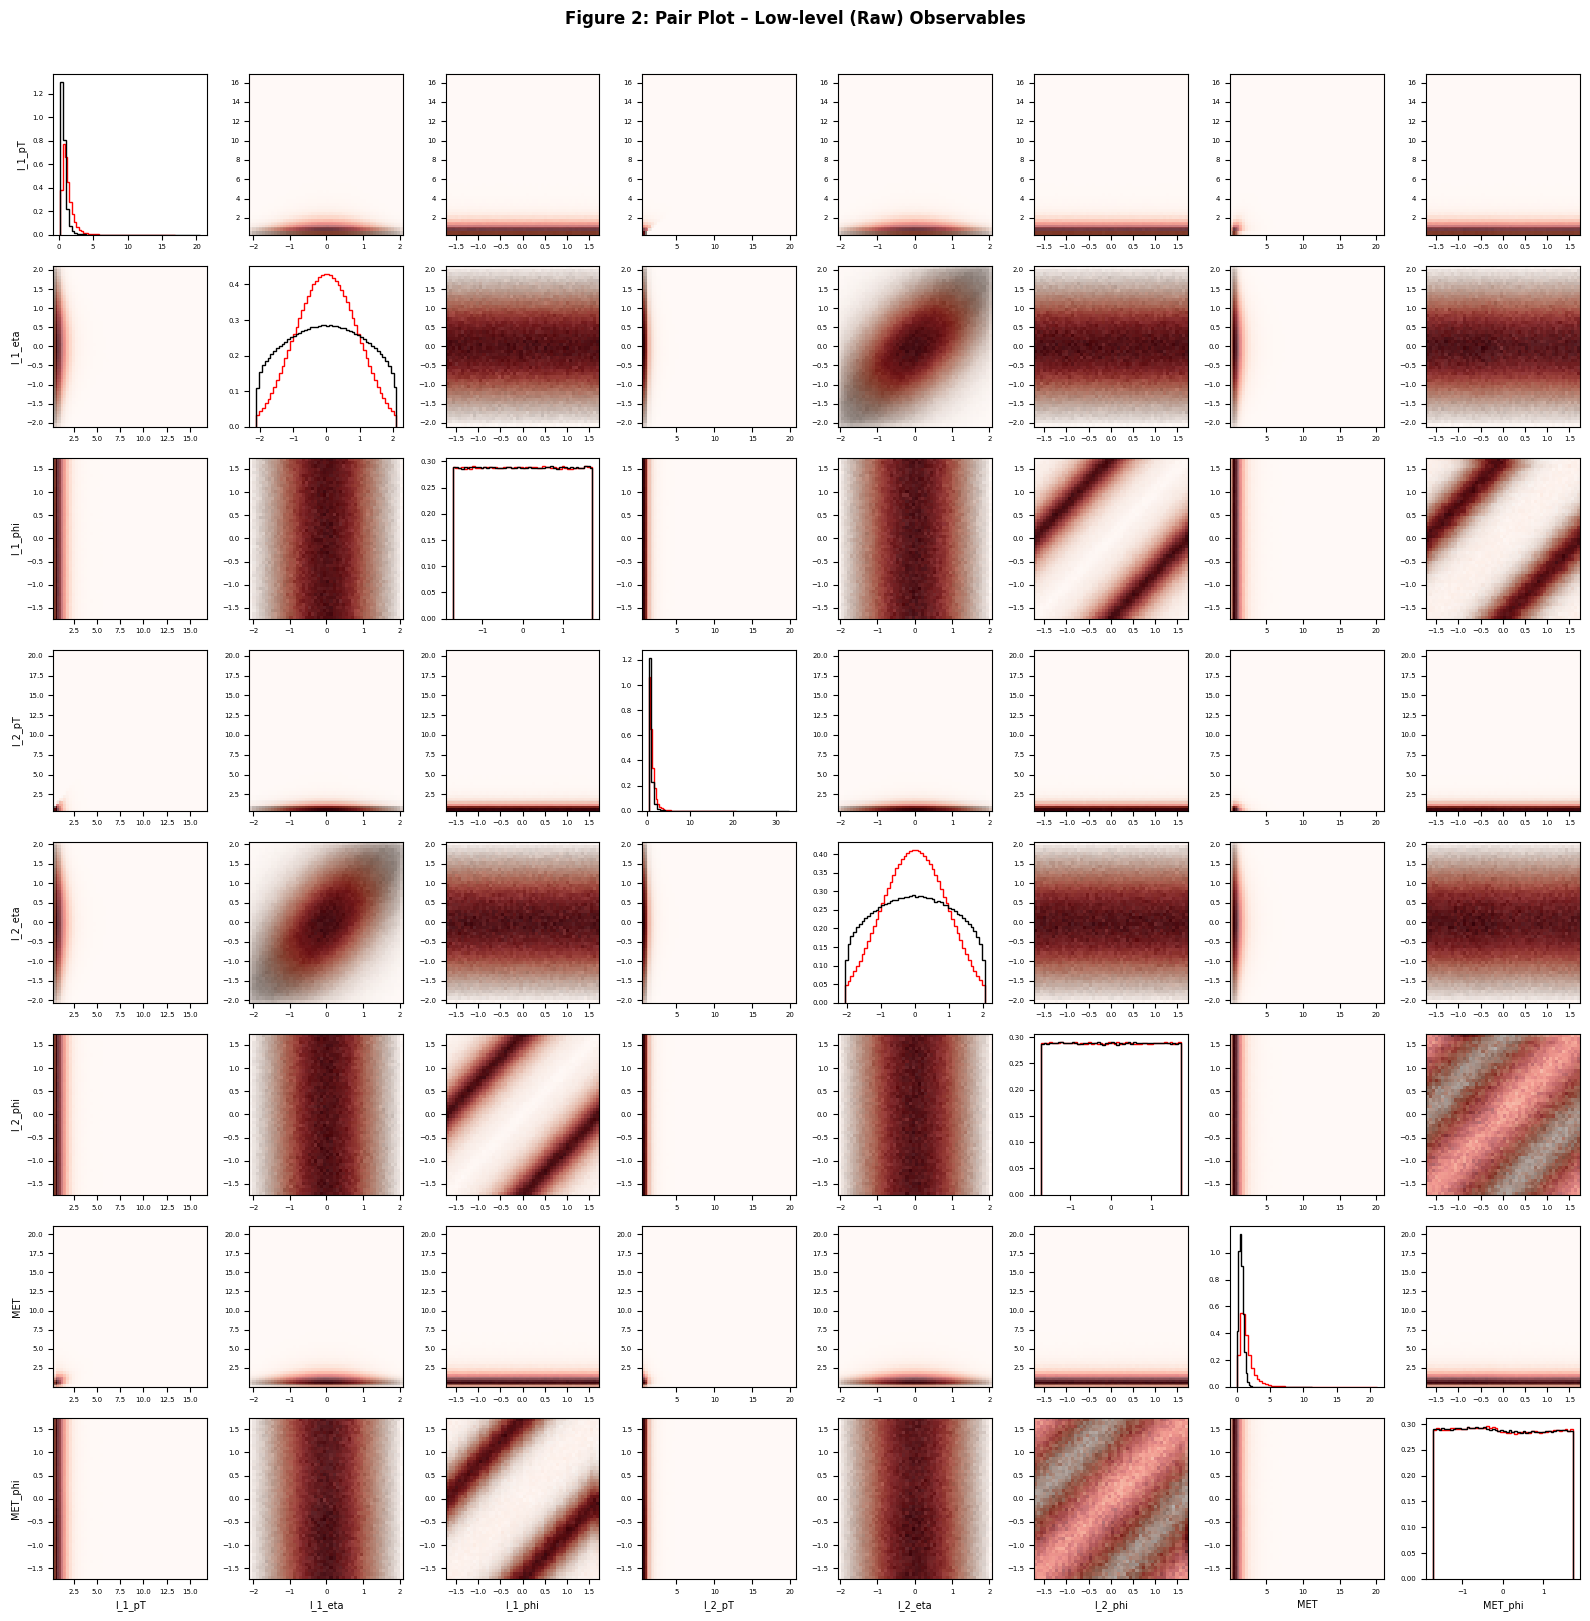

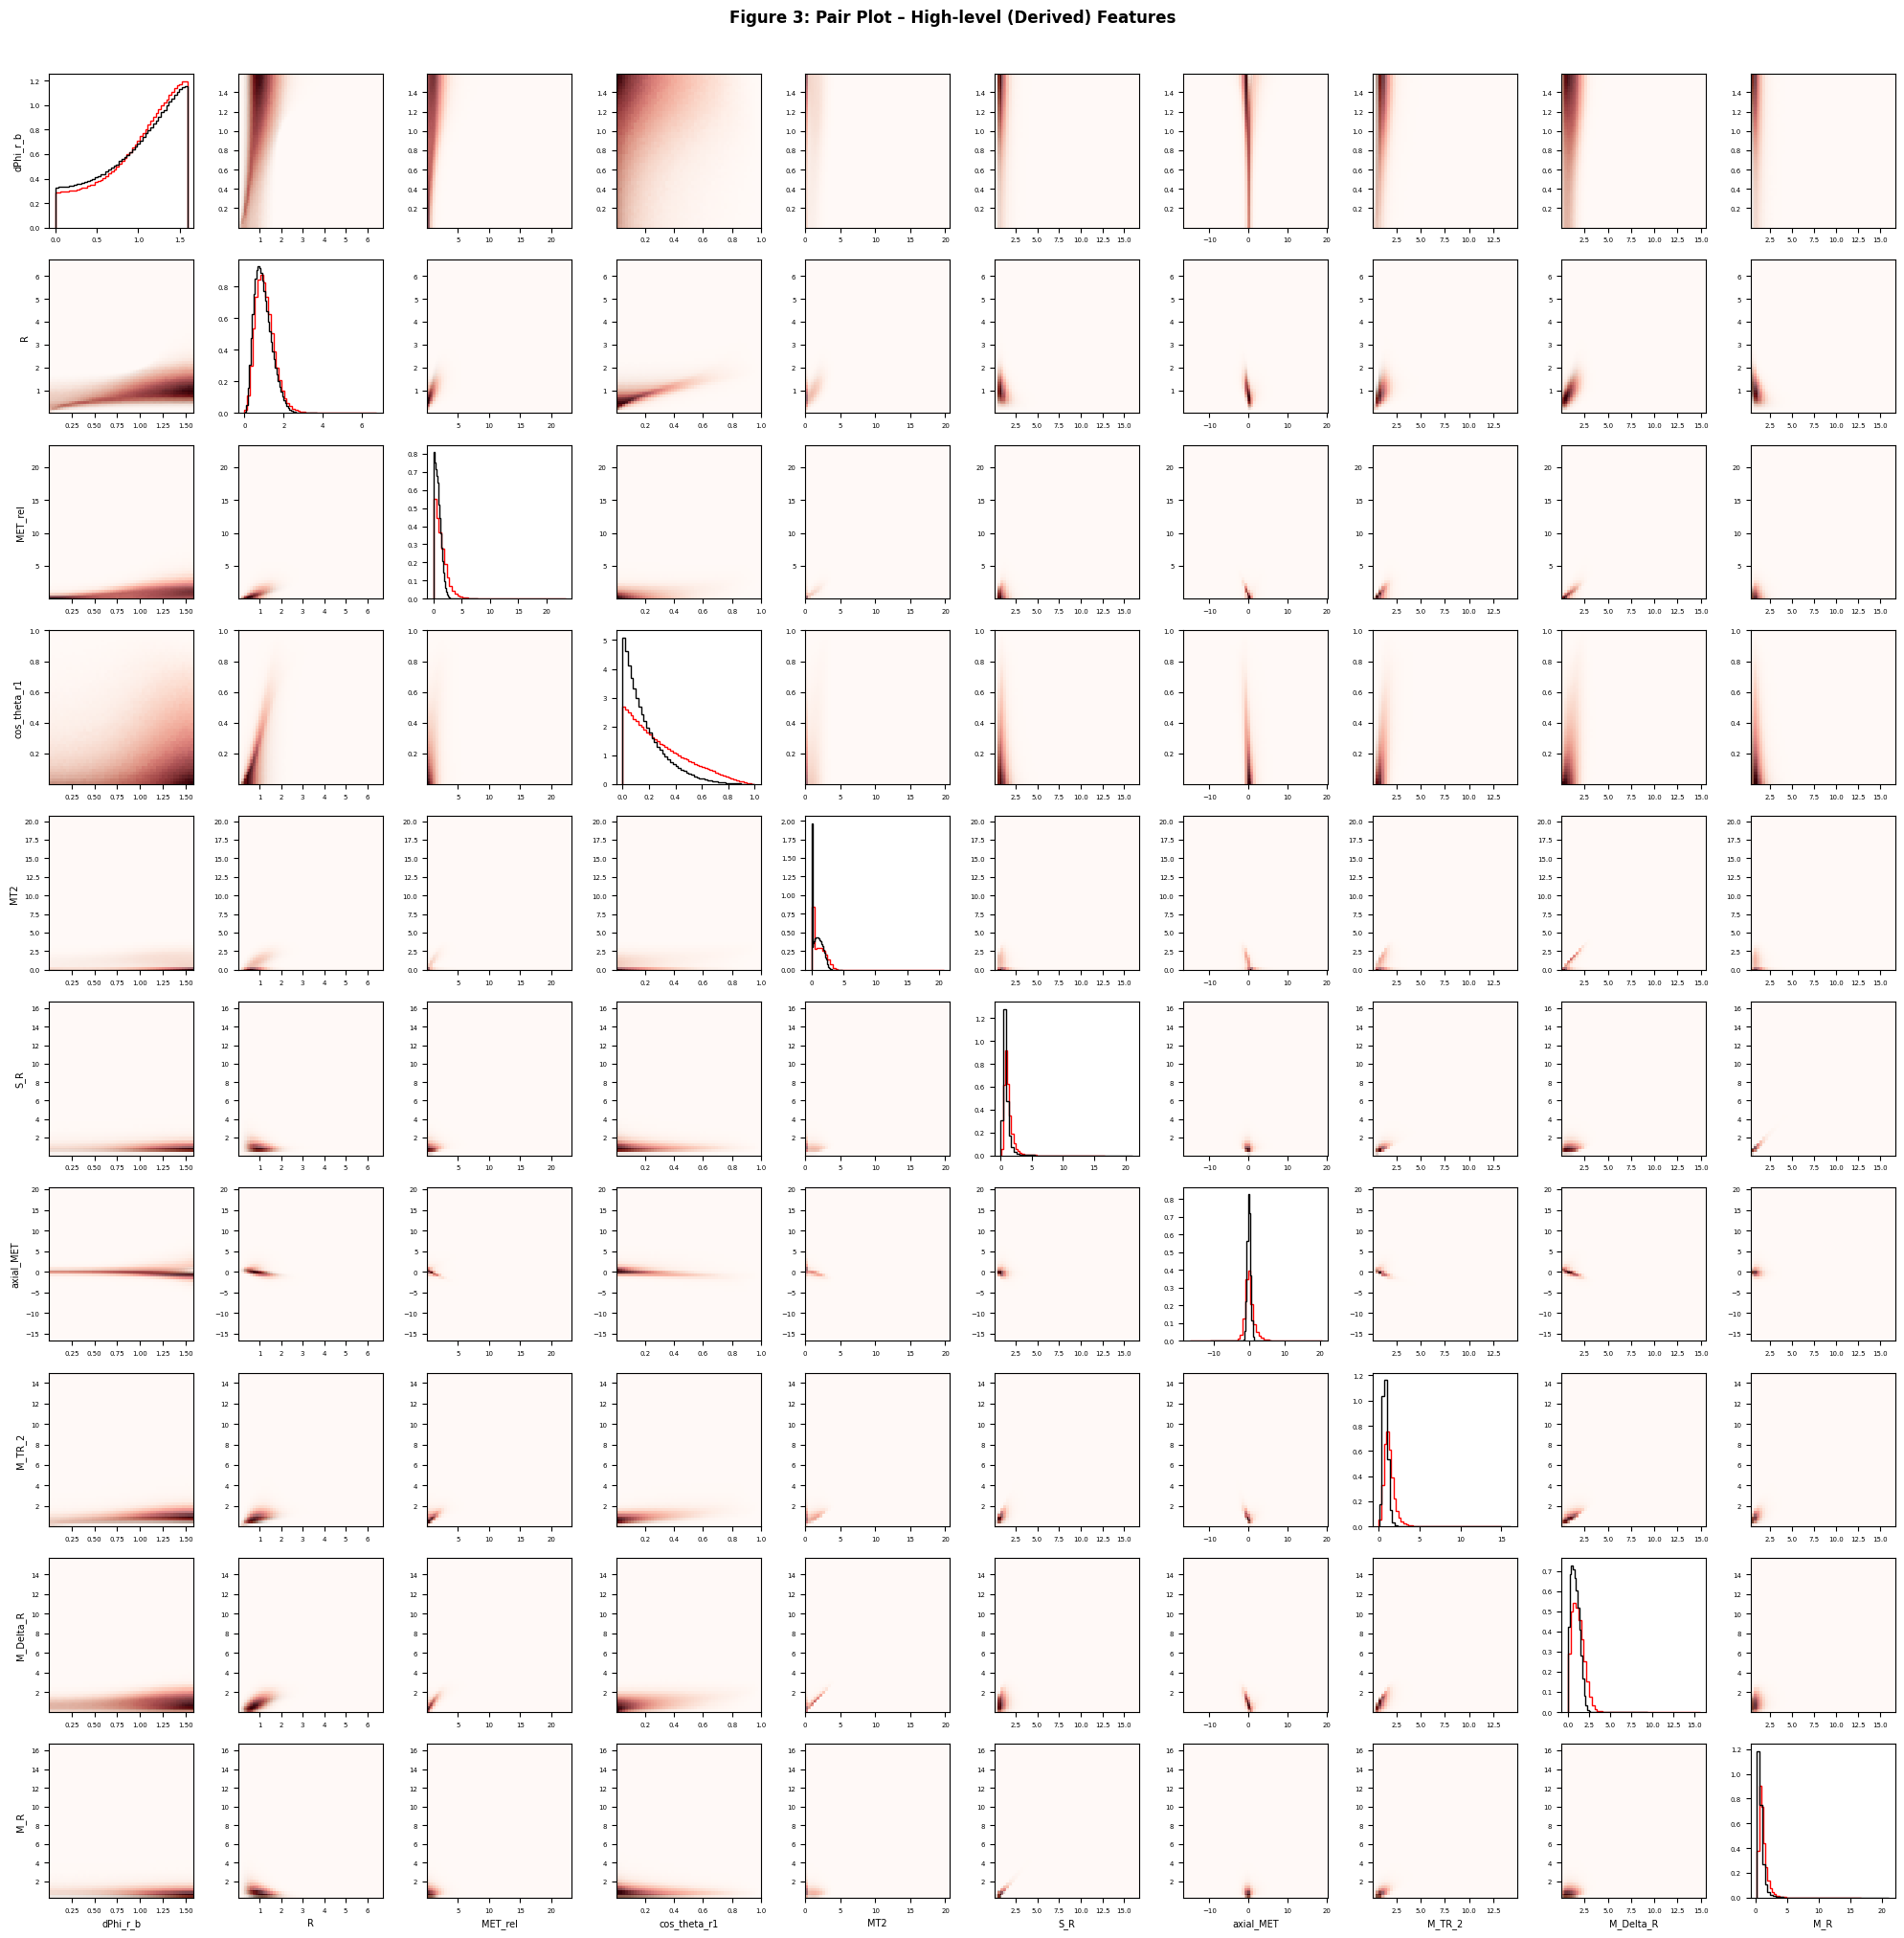

In [24]:
# Part B
# Speed up the process, this will be the optimized version from part A.

import numpy as np
import matplotlib.pyplot as plt

def pair_plot_fast(df_sig, df_bkg, var_list, title="Pair Plot"):
    # What differs here from the prior is optimizations such as pre-extraction
    # All columns are converted to numpy arrays once before the loop begins.
    # Prior, the signla and background were called on every iteration of the double loop, meaning
    # that pandas performed repeated column lookups. Storing arrays in a dict reduces this to a single
    # pass over the data upfront.

    # The other feature to improve speed was hist2d over scatter, though this carried over from part A
    
    n = len(var_list)

    # Speed improvement 1: pre-extract columns as numpy arrays
    # Convert all required columns to numpy arrays once before the loop.
    # This avoids repeated pandas column lookups inside the n x n iteration.
    sig_arrays = {var: df_sig[var].to_numpy() for var in var_list}
    bkg_arrays = {var: df_bkg[var].to_numpy() for var in var_list}

    # Create the n x n subplot grid
    fig, axes = plt.subplots(n, n, figsize=(n * 2, n * 2))

    for i, var_y in enumerate(var_list):
        for j, var_x in enumerate(var_list):

            ax = axes[i, j]

            # Retrieve the pre-computed arrays from the dictionary
            # rather than querying the DataFrame on every iteration
            # This is the process thatll make it faster
            sig_x = sig_arrays[var_x]
            bkg_x = bkg_arrays[var_x]
            sig_y = sig_arrays[var_y]
            bkg_y = bkg_arrays[var_y]

            if i == j:
                # Diagonal: 1D marginal distributions
                ax.hist(sig_x, bins=50, histtype="step",
                        color="red",   density=True)
                ax.hist(bkg_x, bins=50, histtype="step",
                        color="black", density=True)

            else:
                # Off-diagonal: 2D histograms
                # Speed improvement 2 (carried from part a): hist2d bins the
                # data into a fixed grid before rendering, making it much faster
                # than scatter which draws one point per event
                ax.hist2d(bkg_x, bkg_y, bins=50, cmap="Greys", density=True)
                ax.hist2d(sig_x, sig_y, bins=50, cmap="Reds",  density=True,
                          alpha=0.5)

            # Only label outer edges to keep the interior clean
            if i == n - 1:
                ax.set_xlabel(var_x, fontsize=7)
            if j == 0:
                ax.set_ylabel(var_y, fontsize=7)

            ax.tick_params(labelsize=5)

    fig.suptitle(title, fontsize=12, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()


# Part (b): Call the optimised function

pair_plot_fast(df_sig, df_bkg, RawNames,
               title="Figure 2: Pair Plot – Low-level (Raw) Observables")

pair_plot_fast(df_sig, df_bkg, FeatureNames,
               title="Figure 3: Pair Plot – High-level (Derived) Features")

In [25]:
# Part C
# Staying in a code cell format since the prior 2 were code cells

# Low-level (raw) observables — RawNames:
# - l_1_pT and l_1_eta appear decent, can be separated from the background. Same
#   can be said for any iteration of pT and eta. Any iteration of phi was virtually
#   indistinguishable from the background when looking at the signal.

# High-level (derived) features — FeatureNames:
# - Some that can be utilized for separating the signal from the background can be the MET,
#   TR_2, theta_r1, and MET_rel. Others can be utilized, but these are the ones that immediately
#   stand out.

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

In [26]:
# Part A
# Installed, here is a simple test

try:
    import tabulate
    print("tabulate imported successfully, version:", tabulate.__version__)
except ImportError:
    print("tabulate not found — install it with: pip install tabulate")

tabulate imported successfully, version: 0.10.0


In [27]:
# Part B

# Extract all observables (excluding the signal label) as a numpy array
# Rows = events, columns = variables
all_data     = df[VarNames[1:]].to_numpy()
raw_data     = df[RawNames].to_numpy()
feature_data = df[FeatureNames].to_numpy()

# Covariance matrices
# np.cov expects variables as rows, so we transpose (each row = one variable)
cov_all      = np.cov(all_data.T)
cov_raw      = np.cov(raw_data.T)
cov_features = np.cov(feature_data.T)

# Correlation matrices
# np.corrcoef normalises the covariance so all diagonal entries are 1,
# giving a scale-independent measure of linear relationship between variables
corr_all      = np.corrcoef(all_data.T)
corr_raw      = np.corrcoef(raw_data.T)
corr_features = np.corrcoef(feature_data.T)

# Tester - All should come otu to be 1
print("Diagonal of full correlation matrix (should all be 1.0):")
print(np.diag(corr_all).round(6))

Diagonal of full correlation matrix (should all be 1.0):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [28]:
# Part C

# Using gpt to learn tabulate, and it used html, display from ipython.
# I assume if it is from ipython it would be a standard library
from IPython.display import HTML, display
import tabulate as tab

def display_matrix(matrix, var_names, title, fmt=".3f"):
    # Formats a matrix as an HTML table with variable names as headers.

    # Build rows: prepend each row with its variable name as a row label
    # format(val, fmt) controls decimal places for each matrix entry
    rows = [[var_names[i]] + [format(val, fmt) for val in row]
            for i, row in enumerate(matrix)]

    # Print title above table, then render as HTML in the notebook
    print(title)
    display(HTML(tab.tabulate(rows, headers=[""] + var_names, tablefmt="html")))


# Testing section

# Raw - low level
# Covariance shows absolute spread, correlation shows scale-independent relationship
display_matrix(cov_raw,       RawNames,     "Covariance – Raw Observables")
display_matrix(corr_raw,      RawNames,     "Correlation – Raw Observables")

# Hiwh level
display_matrix(cov_features,  FeatureNames, "Covariance – High-level Features")
display_matrix(corr_features, FeatureNames, "Correlation – High-level Features")

# all obeservables
display_matrix(cov_all,       VarNames[1:], "Covariance – All Observables")
display_matrix(corr_all,      VarNames[1:], "Correlation – All Observables")

Covariance – Raw Observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,0.472,-0,-0,0.308,-0,0,0.231,-0.001
l_1_eta,-0,1.006,0,-0,0.406,0,-0.001,-0.001
l_1_phi,-0,0,1.003,-0,0.001,-0.268,0.001,-0.184
l_2_pT,0.308,-0,-0,0.428,-0,0,0.08,-0.001
l_2_eta,-0,0.406,0.001,-0,1.006,-0,0,-0
l_2_phi,0,0,-0.268,0,-0,1.003,0,-0.034
MET,0.231,-0.001,0.001,0.08,0,0,0.762,-0.002
MET_phi,-0.001,-0.001,-0.184,-0.001,-0,-0.034,-0.002,1.003


Correlation – Raw Observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0,-0,0.685,-0,0,0.385,-0.001
l_1_eta,-0,1,0,-0.001,0.403,0,-0.001,-0.001
l_1_phi,-0,0,1,-0,0.001,-0.267,0.001,-0.184
l_2_pT,0.685,-0.001,-0,1,-0.001,0,0.14,-0.002
l_2_eta,-0,0.403,0.001,-0.001,1,-0,0,-0
l_2_phi,0,0,-0.267,0,-0,1,0,-0.034
MET,0.385,-0.001,0.001,0.14,0,0,1,-0.002
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.034,-0.002,1


Covariance – High-level Features


...

,dPhi_r_b,R,MET_rel,cos_theta_r1,MT2,S_R,axial_MET,M_TR_2,M_Delta_R,M_R
dPhi_r_b,1,0.424,0.378,0.106,0.056,-0.013,-0.06,0.228,0.156,-0.106
R,0.424,1,0.595,0.627,0.574,-0.285,-0.385,0.38,0.564,-0.381
MET_rel,0.378,0.595,1,0.317,0.536,0.149,-0.141,0.583,0.749,0.078
cos_theta_r1,0.106,0.627,0.317,1,0.263,-0.084,-0.274,0.451,0.319,-0.115
MT2,0.056,0.574,0.536,0.263,1,-0.021,-0.535,0.378,0.808,-0.068
S_R,-0.013,-0.285,0.149,-0.084,-0.021,1,-0.07,0.636,0.248,0.981
axial_MET,-0.06,-0.385,-0.141,-0.274,-0.535,-0.07,1,-0.323,-0.375,0.024
M_TR_2,0.228,0.38,0.583,0.451,0.378,0.636,-0.323,1,0.666,0.578
M_Delta_R,0.156,0.564,0.749,0.319,0.808,0.248,-0.375,0.666,1,0.189
M_R,-0.106,-0.381,0.078,-0.115,-0.068,0.981,0.024,0.578,0.189,1


Covariance – All Observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,0.472,-0,-0,0.308,-0,0,0.231,-0.001,0.099,-0.013,0.368,0.291,-0.059,-0.013,0.346,0.098,-0.047,0.023
l_1_eta,-0,1.006,0,-0,0.406,0,-0.001,-0.001,-0,-0,-0,-0,0,-0,-0,-0.001,0,0
l_1_phi,-0,0,1.003,-0,0.001,-0.268,0.001,-0.184,0.002,-0.002,-0,0.001,0.001,0.002,0,0.001,0.001,0
l_2_pT,0.308,-0,-0,0.428,-0,0,0.08,-0.001,-0.002,0.05,0.328,0.164,-0.099,-0.069,0.325,0.006,-0.004,-0.028
l_2_eta,-0,0.406,0.001,-0,1.006,-0,0,-0,0,-0,-0.001,-0,0,-0,-0.001,-0,-0,0
l_2_phi,0,0,-0.268,0,-0,1.003,0,-0.034,0,-0,0,0,0,0.001,0,0,0,-0
MET,0.231,-0.001,0.001,0.08,0,0,0.762,-0.002,0.548,0.145,0.146,0.368,0.189,0.156,0.167,0.317,0.145,0.073
MET_phi,-0.001,-0.001,-0.184,-0.001,-0,-0.034,-0.002,1.003,-0.003,-0.001,-0.001,-0.001,-0,0.001,-0.001,-0,-0.001,0
MET_rel,0.099,-0,0.002,-0.002,0,0,0.548,-0.003,0.792,-0.125,0.044,0.303,0.25,0.41,0.082,0.416,0.147,0.056
axial_MET,-0.013,-0,-0.002,0.05,-0,-0,0.145,-0.001,-0.125,1.003,0.015,-0.189,-0.182,-0.46,-0.043,-0.234,-0.026,-0.054


Correlation – All Observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,1,-0,-0,0.685,-0,0,0.385,-0.001,0.161,-0.018,0.852,0.724,-0.183,-0.022,0.812,0.229,-0.157,0.166
l_1_eta,-0,1,0,-0.001,0.403,0,-0.001,-0.001,-0.001,-0,-0,-0,0,-0,-0,-0.001,0,0.001
l_1_phi,-0,0,1,-0,0.001,-0.267,0.001,-0.184,0.002,-0.002,-0,0.001,0.002,0.002,0,0.002,0.002,0.002
l_2_pT,0.685,-0.001,-0,1,-0.001,0,0.14,-0.002,-0.004,0.076,0.798,0.43,-0.322,-0.123,0.799,0.014,-0.014,-0.216
l_2_eta,-0,0.403,0.001,-0.001,1,-0,0,-0,0,-0,-0.001,-0,0.001,-0,-0.001,-0,-0,0.001
l_2_phi,0,0,-0.267,0,-0,1,0,-0.034,0,-0,0,0,0,0.001,0.001,0.001,0.001,-0.001
MET,0.385,-0.001,0.001,0.14,0,0,1,-0.002,0.706,0.166,0.266,0.722,0.459,0.209,0.309,0.581,0.382,0.426
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.034,-0.002,1,-0.003,-0.001,-0.002,-0.001,-0,0.001,-0.002,-0.001,-0.003,0
MET_rel,0.161,-0.001,0.002,-0.004,0,0,0.706,-0.003,1,-0.141,0.078,0.583,0.595,0.536,0.149,0.749,0.378,0.317
axial_MET,-0.018,-0,-0.002,0.076,-0,-0,0.166,-0.001,-0.141,1,0.024,-0.323,-0.385,-0.535,-0.07,-0.375,-0.06,-0.274


In [29]:
# Part D

def matrix_report(data, var_names, title_prefix, fmt=".3f"):
    # Computes and displays covariance and correlation matrices for a given dataset.
    # Combines steps b and c into a single reusable function.
        # data         : 2D numpy array of shape (n_events, n_variables)
        # var_names    : list of variable name strings matching the columns of data
        # title_prefix : string label prepended to each table title
        # fmt          : decimal format string for matrix entries, default 3dp
    

    # Compute covariance and correlation matrices
    # np.cov / np.corrcoef expect variables as rows, so transpose
    cov  = np.cov(data.T)
    corr = np.corrcoef(data.T)

    # Display both matrices using the function from part c
    display_matrix(cov,  var_names, f"Covariance – {title_prefix}",  fmt)
    display_matrix(corr, var_names, f"Correlation – {title_prefix}", fmt)


# ── Call for each variable grouping ───────────────────────────────────────────
matrix_report(raw_data,     RawNames,     "Raw Observables")
matrix_report(feature_data, FeatureNames, "High-level Features")
matrix_report(all_data,     VarNames[1:], "All Observables")

Covariance – Raw Observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,0.472,-0,-0,0.308,-0,0,0.231,-0.001
l_1_eta,-0,1.006,0,-0,0.406,0,-0.001,-0.001
l_1_phi,-0,0,1.003,-0,0.001,-0.268,0.001,-0.184
l_2_pT,0.308,-0,-0,0.428,-0,0,0.08,-0.001
l_2_eta,-0,0.406,0.001,-0,1.006,-0,0,-0
l_2_phi,0,0,-0.268,0,-0,1.003,0,-0.034
MET,0.231,-0.001,0.001,0.08,0,0,0.762,-0.002
MET_phi,-0.001,-0.001,-0.184,-0.001,-0,-0.034,-0.002,1.003


Correlation – Raw Observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0,-0,0.685,-0,0,0.385,-0.001
l_1_eta,-0,1,0,-0.001,0.403,0,-0.001,-0.001
l_1_phi,-0,0,1,-0,0.001,-0.267,0.001,-0.184
l_2_pT,0.685,-0.001,-0,1,-0.001,0,0.14,-0.002
l_2_eta,-0,0.403,0.001,-0.001,1,-0,0,-0
l_2_phi,0,0,-0.267,0,-0,1,0,-0.034
MET,0.385,-0.001,0.001,0.14,0,0,1,-0.002
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.034,-0.002,1


Covariance – High-level Features


...

,dPhi_r_b,R,MET_rel,cos_theta_r1,MT2,S_R,axial_MET,M_TR_2,M_Delta_R,M_R
dPhi_r_b,1,0.424,0.378,0.106,0.056,-0.013,-0.06,0.228,0.156,-0.106
R,0.424,1,0.595,0.627,0.574,-0.285,-0.385,0.38,0.564,-0.381
MET_rel,0.378,0.595,1,0.317,0.536,0.149,-0.141,0.583,0.749,0.078
cos_theta_r1,0.106,0.627,0.317,1,0.263,-0.084,-0.274,0.451,0.319,-0.115
MT2,0.056,0.574,0.536,0.263,1,-0.021,-0.535,0.378,0.808,-0.068
S_R,-0.013,-0.285,0.149,-0.084,-0.021,1,-0.07,0.636,0.248,0.981
axial_MET,-0.06,-0.385,-0.141,-0.274,-0.535,-0.07,1,-0.323,-0.375,0.024
M_TR_2,0.228,0.38,0.583,0.451,0.378,0.636,-0.323,1,0.666,0.578
M_Delta_R,0.156,0.564,0.749,0.319,0.808,0.248,-0.375,0.666,1,0.189
M_R,-0.106,-0.381,0.078,-0.115,-0.068,0.981,0.024,0.578,0.189,1


Covariance – All Observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,0.472,-0,-0,0.308,-0,0,0.231,-0.001,0.099,-0.013,0.368,0.291,-0.059,-0.013,0.346,0.098,-0.047,0.023
l_1_eta,-0,1.006,0,-0,0.406,0,-0.001,-0.001,-0,-0,-0,-0,0,-0,-0,-0.001,0,0
l_1_phi,-0,0,1.003,-0,0.001,-0.268,0.001,-0.184,0.002,-0.002,-0,0.001,0.001,0.002,0,0.001,0.001,0
l_2_pT,0.308,-0,-0,0.428,-0,0,0.08,-0.001,-0.002,0.05,0.328,0.164,-0.099,-0.069,0.325,0.006,-0.004,-0.028
l_2_eta,-0,0.406,0.001,-0,1.006,-0,0,-0,0,-0,-0.001,-0,0,-0,-0.001,-0,-0,0
l_2_phi,0,0,-0.268,0,-0,1.003,0,-0.034,0,-0,0,0,0,0.001,0,0,0,-0
MET,0.231,-0.001,0.001,0.08,0,0,0.762,-0.002,0.548,0.145,0.146,0.368,0.189,0.156,0.167,0.317,0.145,0.073
MET_phi,-0.001,-0.001,-0.184,-0.001,-0,-0.034,-0.002,1.003,-0.003,-0.001,-0.001,-0.001,-0,0.001,-0.001,-0,-0.001,0
MET_rel,0.099,-0,0.002,-0.002,0,0,0.548,-0.003,0.792,-0.125,0.044,0.303,0.25,0.41,0.082,0.416,0.147,0.056
axial_MET,-0.013,-0,-0.002,0.05,-0,-0,0.145,-0.001,-0.125,1.003,0.015,-0.189,-0.182,-0.46,-0.043,-0.234,-0.026,-0.054


Correlation – All Observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,1,-0,-0,0.685,-0,0,0.385,-0.001,0.161,-0.018,0.852,0.724,-0.183,-0.022,0.812,0.229,-0.157,0.166
l_1_eta,-0,1,0,-0.001,0.403,0,-0.001,-0.001,-0.001,-0,-0,-0,0,-0,-0,-0.001,0,0.001
l_1_phi,-0,0,1,-0,0.001,-0.267,0.001,-0.184,0.002,-0.002,-0,0.001,0.002,0.002,0,0.002,0.002,0.002
l_2_pT,0.685,-0.001,-0,1,-0.001,0,0.14,-0.002,-0.004,0.076,0.798,0.43,-0.322,-0.123,0.799,0.014,-0.014,-0.216
l_2_eta,-0,0.403,0.001,-0.001,1,-0,0,-0,0,-0,-0.001,-0,0.001,-0,-0.001,-0,-0,0.001
l_2_phi,0,0,-0.267,0,-0,1,0,-0.034,0,-0,0,0,0,0.001,0.001,0.001,0.001,-0.001
MET,0.385,-0.001,0.001,0.14,0,0,1,-0.002,0.706,0.166,0.266,0.722,0.459,0.209,0.309,0.581,0.382,0.426
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.034,-0.002,1,-0.003,-0.001,-0.002,-0.001,-0,0.001,-0.002,-0.001,-0.003,0
MET_rel,0.161,-0.001,0.002,-0.004,0,0,0.706,-0.003,1,-0.141,0.078,0.583,0.595,0.536,0.149,0.749,0.378,0.317
axial_MET,-0.018,-0,-0.002,0.076,-0,-0,0.166,-0.001,-0.141,1,0.024,-0.323,-0.385,-0.535,-0.07,-0.375,-0.06,-0.274


Hint: Example code for embedding a `tabulate` table into a notebook:

In [30]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


### Stopping Here - 3/27/2026

### Resuming - 4/3/2026

In [31]:
# Reload from the reduced dataset for Exercise 5 onwards
filename = "SUSY-small.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

df_sig = df[df.signal == 1]
df_bkg = df[df.signal == 0]

print(f"Loaded {len(df):,} events  |  {len(df_sig):,} signal  |  {len(df_bkg):,} background")

Loaded 500,000 events  |  229,245 signal  |  270,755 background


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

In [32]:
# Part 1

# This section is to determine the optimal cut type for each observable by comparting
# its background signal & background means & background standard deviations
#
# There are 4 possible cut strategies, as illistruted above
# 1 - signal sits higher
# 2 - signal sits lower
# 3 - signal is more concentrated
# 4 - signal is more spread out
#
# in deciding which applies best, we compare how far apart the signal and background means are relative to the combined spread.
# If the means are well separated, a simple threshold cut (1 and 2) is appropriate.
# If the means are close but the widths differ, an absolute-value cut is better.

# imports
import numpy as np
from tabulate import tabulate
from IPython.display import HTML, display

# preextract all observable columns as numpy arrays once upfront, this will avoiud repeated pandas column lookups in
# the loop below, these dicts will then carry forward into 5 part 2 and 3. NOTE: Run this cell before the next 2
sig_arrs = {var: df_sig[var].to_numpy() for var in VarNames[1:]}
bkg_arrs = {var: df_bkg[var].to_numpy() for var in VarNames[1:]}

def determine_cut(sig_arr, bkg_arr):
    # this is to compute the mean and standard for the signal and background
    sm, ss = sig_arr.mean(), sig_arr.std()
    bm, bs = bkg_arr.mean(), bkg_arr.std()

    # Pooled std gives a single measure of combined spread for comparison
    pooled = (ss + bs) / 2

    # Midpoint between the two means
    mu = (sm + bm) / 2

    # If the means are separated by at least half the pooled spread, a simple threshold cut will be effective, like in 1 & 2
    if abs(sm - bm) >= 0.5 * pooled:
        # Signal sitting higher means we want to keep high-value events
        cut = "x > x_c" if sm > bm else "x < x_c"
    else:
        # Other case is means are too similar, discrimination comes from width diff instead. If signal is narrower,
        # cutting close to the center keeps it. If the signal is broader, cutting away from the center keeps it.
        cut = "|x - mu| < x_c" if ss < bs else "|x - mu| > x_c"

    return cut, mu, sm, bm, ss, bs

# This section loops over every observable, determines its cut type, and will collect the results into a list
# of rows for the sum table. This is where tabulate becomes useful.
cut_info = {}   # stores (cut_type, mu) for each variable - used in part b and part c of this exercise
rows = []
for var in VarNames[1:]:
    cut, mu, sm, bm, ss, bs = determine_cut(sig_arrs[var], bkg_arrs[var])
    cut_info[var] = (cut, mu)
    rows.append([var, f"{sm:.3f}", f"{bm:.3f}", f"{ss:.3f}", f"{bs:.3f}", cut])

# Display as an HTML table using tabulate, same as in exercise 4
headers = ["Variable", "Signal Mean", "Bkg Mean", "Signal Std", "Bkg Std", "Cut Type"]
display(HTML(tabulate(rows, headers=headers, tablefmt="html")))

Variable,Signal Mean,Bkg Mean,Signal Std,Bkg Std,Cut Type
l_1_pT,1.291,0.754,0.799,0.437,x > x_c
l_1_eta,0.001,-0,0.866,1.104,|x - mu| < x_c
l_1_phi,-0.002,-0.002,1.002,1.002,|x - mu| < x_c
l_2_pT,1.139,0.881,0.743,0.537,|x - mu| > x_c
l_2_eta,0.002,-0,0.89,1.09,|x - mu| < x_c
l_2_phi,0,-0.001,1.002,1.002,|x - mu| > x_c
MET,1.418,0.648,1.094,0.35,x > x_c
MET_phi,-0,0.001,1.001,1.002,|x - mu| < x_c
MET_rel,1.275,0.77,1.11,0.548,x > x_c
axial_MET,0.089,-0.07,1.382,0.477,|x - mu| > x_c


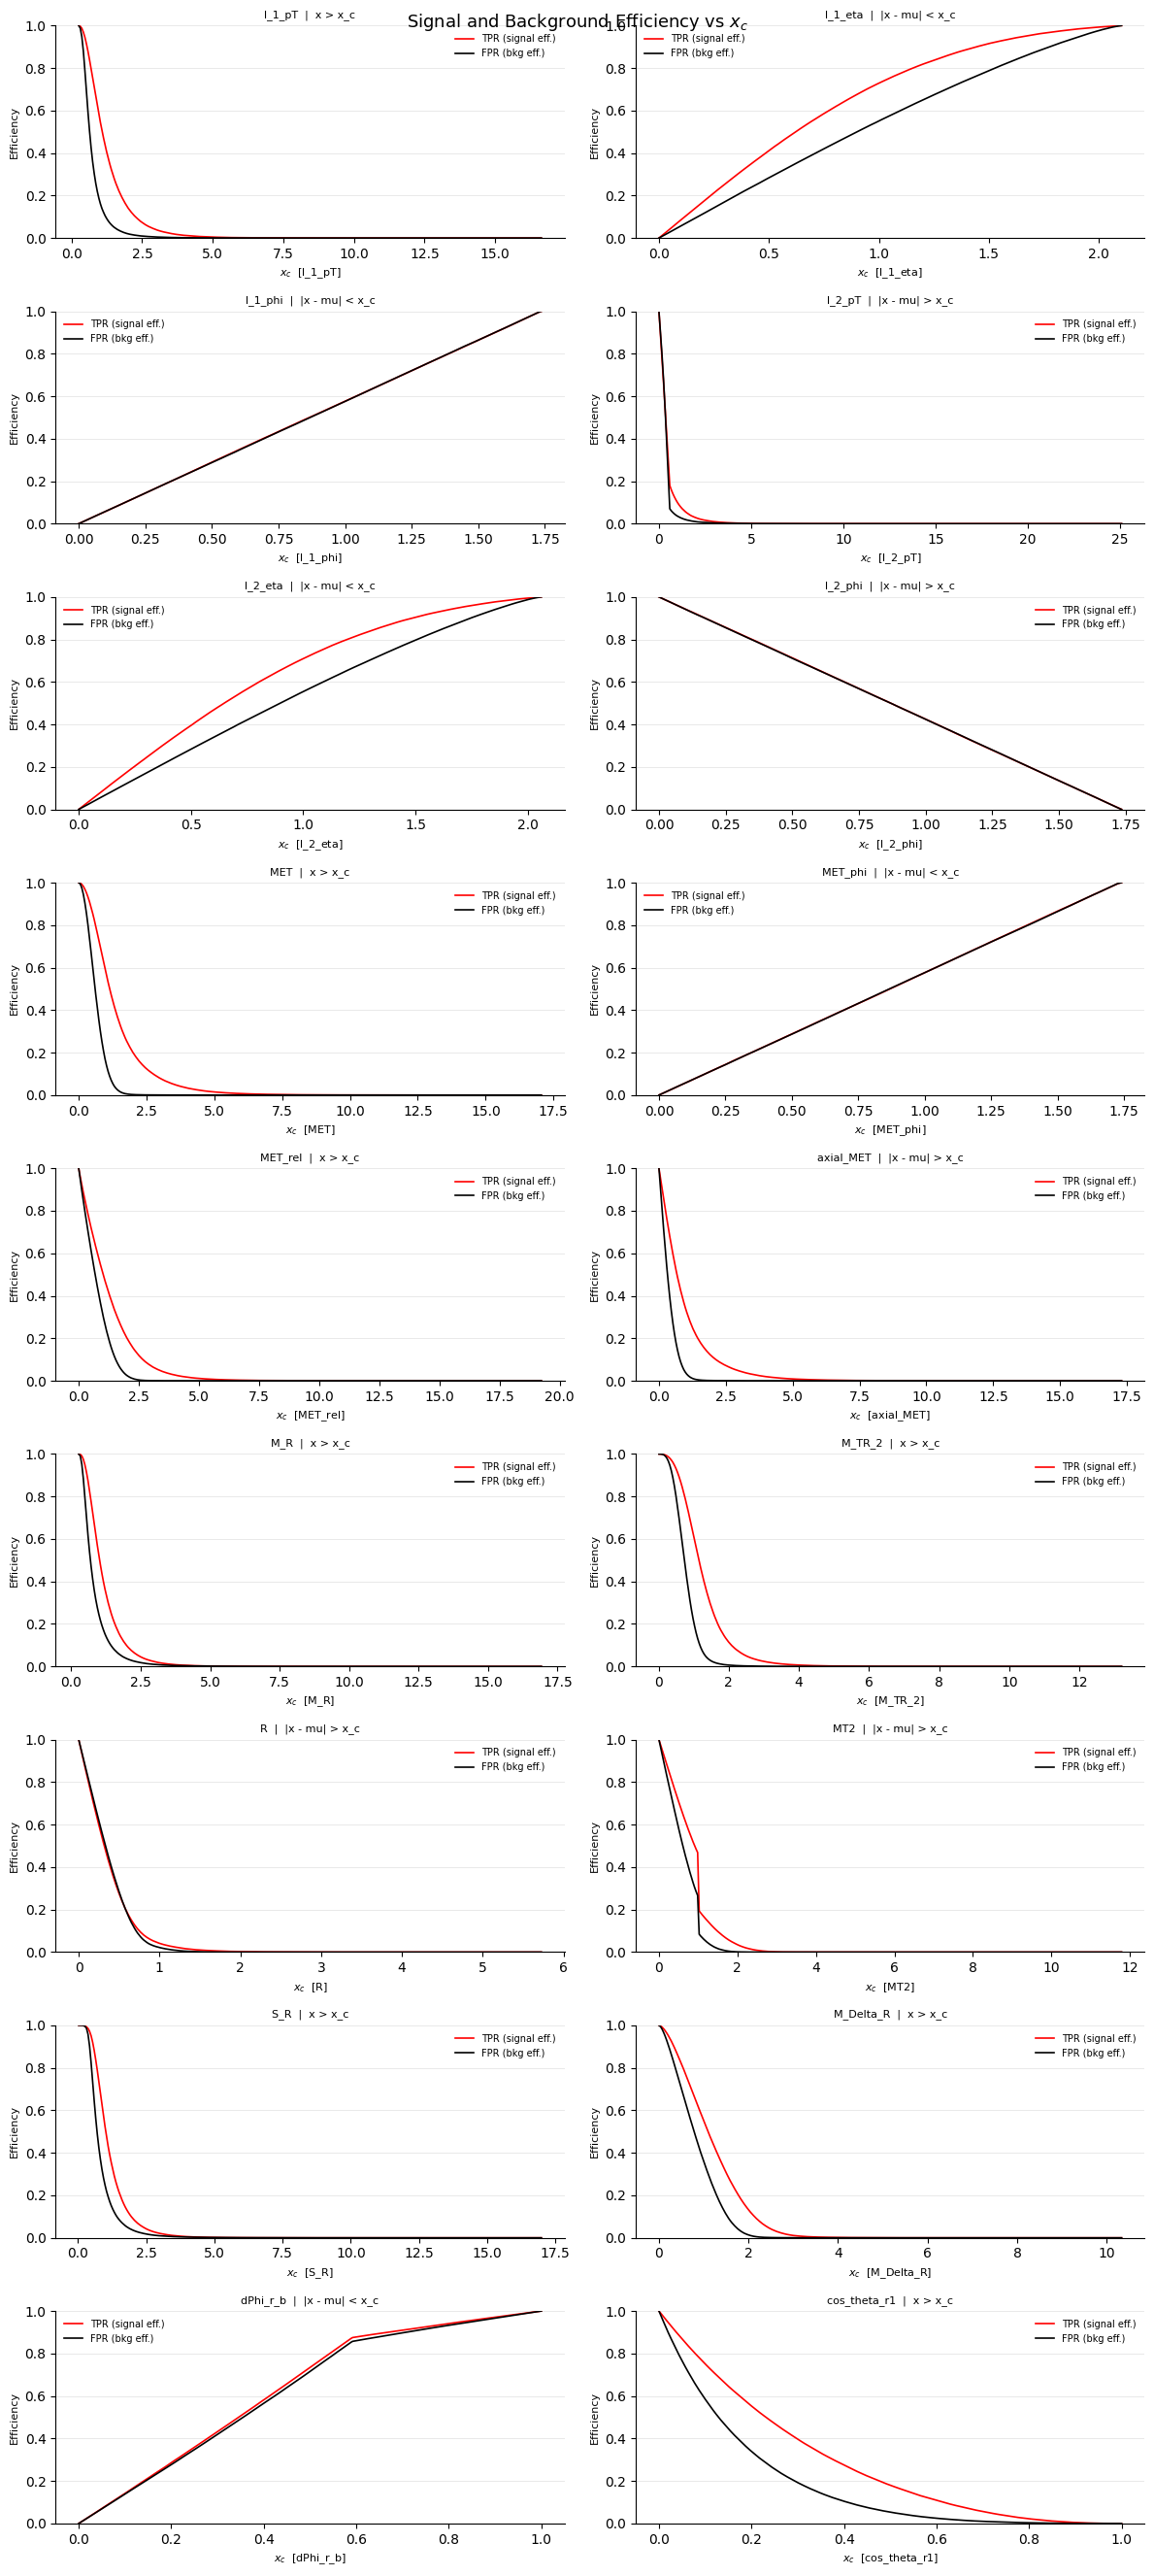

In [33]:
# Part 2

# plot the signal efficiency and background efficiency vs x_c for each observable using the cut type determined in the last part
#
# For each variable we will take x_c and chekc it across the full range of the data and see what fraction of
# the signal and background events pass the cut at each val of x_c.
#
# Speed note: instead of looping over every x_c value and scanning the full array each time (O(n * m)), we sort the array once and use
# searchsorted to find the cutoff position in O(log n) per query. This is the same principle as the pre-extraction speedup from exercise 4.

# import - redundant but doesnt hurt to do again if this is run out of order
import matplotlib.pyplot as plt

def compute_efficiency(arr, cut_type, mu, xc_vals):
    # sort the array once, use searchsorted to count how manyt events fall on each side of the x_c threshold
    if cut_type == "x > x_c":
        # Fraction above x_c = 1 - fraction at or below x_c
        s = np.sort(arr)
        return 1.0 - np.searchsorted(s, xc_vals, side="left") / len(arr)
    elif cut_type == "x < x_c":
        # Fraction strictly below x_c
        s = np.sort(arr)
        return np.searchsorted(s, xc_vals, side="right") / len(arr)
    elif cut_type == "|x - mu| < x_c":
        # Fraction whose distance from mu is less than x_c
        s = np.sort(np.abs(arr - mu))
        return np.searchsorted(s, xc_vals, side="right") / len(arr)
    else:
        # |x - mu| > x_c: fraction whose distance from mu exceeds x_c
        s = np.sort(np.abs(arr - mu))
        return 1.0 - np.searchsorted(s, xc_vals, side="left") / len(arr)

N_POINTS = 300
ncols = 2
nrows = int(np.ceil(len(VarNames[1:]) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 3))
axes = axes.flatten()

for ax, var in zip(axes, VarNames[1:]):
    cut_type, mu = cut_info[var]
    sa, ba = sig_arrs[var], bkg_arrs[var]

    # For abs val cuts, x_c is a distance from mu rather than a raw value, so we build the sweep range over |x - mu| instead of x itself
    if "mu" in cut_type:
        combined = np.abs(np.concatenate([sa, ba]) - mu)
    else:
        combined = np.concatenate([sa, ba])
    xc_vals = np.linspace(combined.min(), combined.max(), N_POINTS)

    # Compute signal (TPR) and background (FPR) efficiency across the x_c sweep
    tpr = compute_efficiency(sa, cut_type, mu, xc_vals)
    fpr = compute_efficiency(ba, cut_type, mu, xc_vals)

    ax.plot(xc_vals, tpr, color="red",   lw=1.2, label="TPR (signal eff.)")
    ax.plot(xc_vals, fpr, color="black", lw=1.2, label="FPR (bkg eff.)")
    ax.set_xlabel(f"$x_c$  [{var}]", fontsize=8)
    ax.set_ylabel("Efficiency", fontsize=8)
    ax.set_title(f"{var}  |  {cut_type}", fontsize=8)
    ax.legend(fontsize=7, frameon=False)
    ax.set_ylim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, lw=0.4, alpha=0.5)

for ax in axes[len(VarNames[1:]):]:
    ax.set_visible(False)

fig.suptitle("Signal and Background Efficiency vs $x_c$", fontsize=13)
fig.tight_layout()
plt.show()

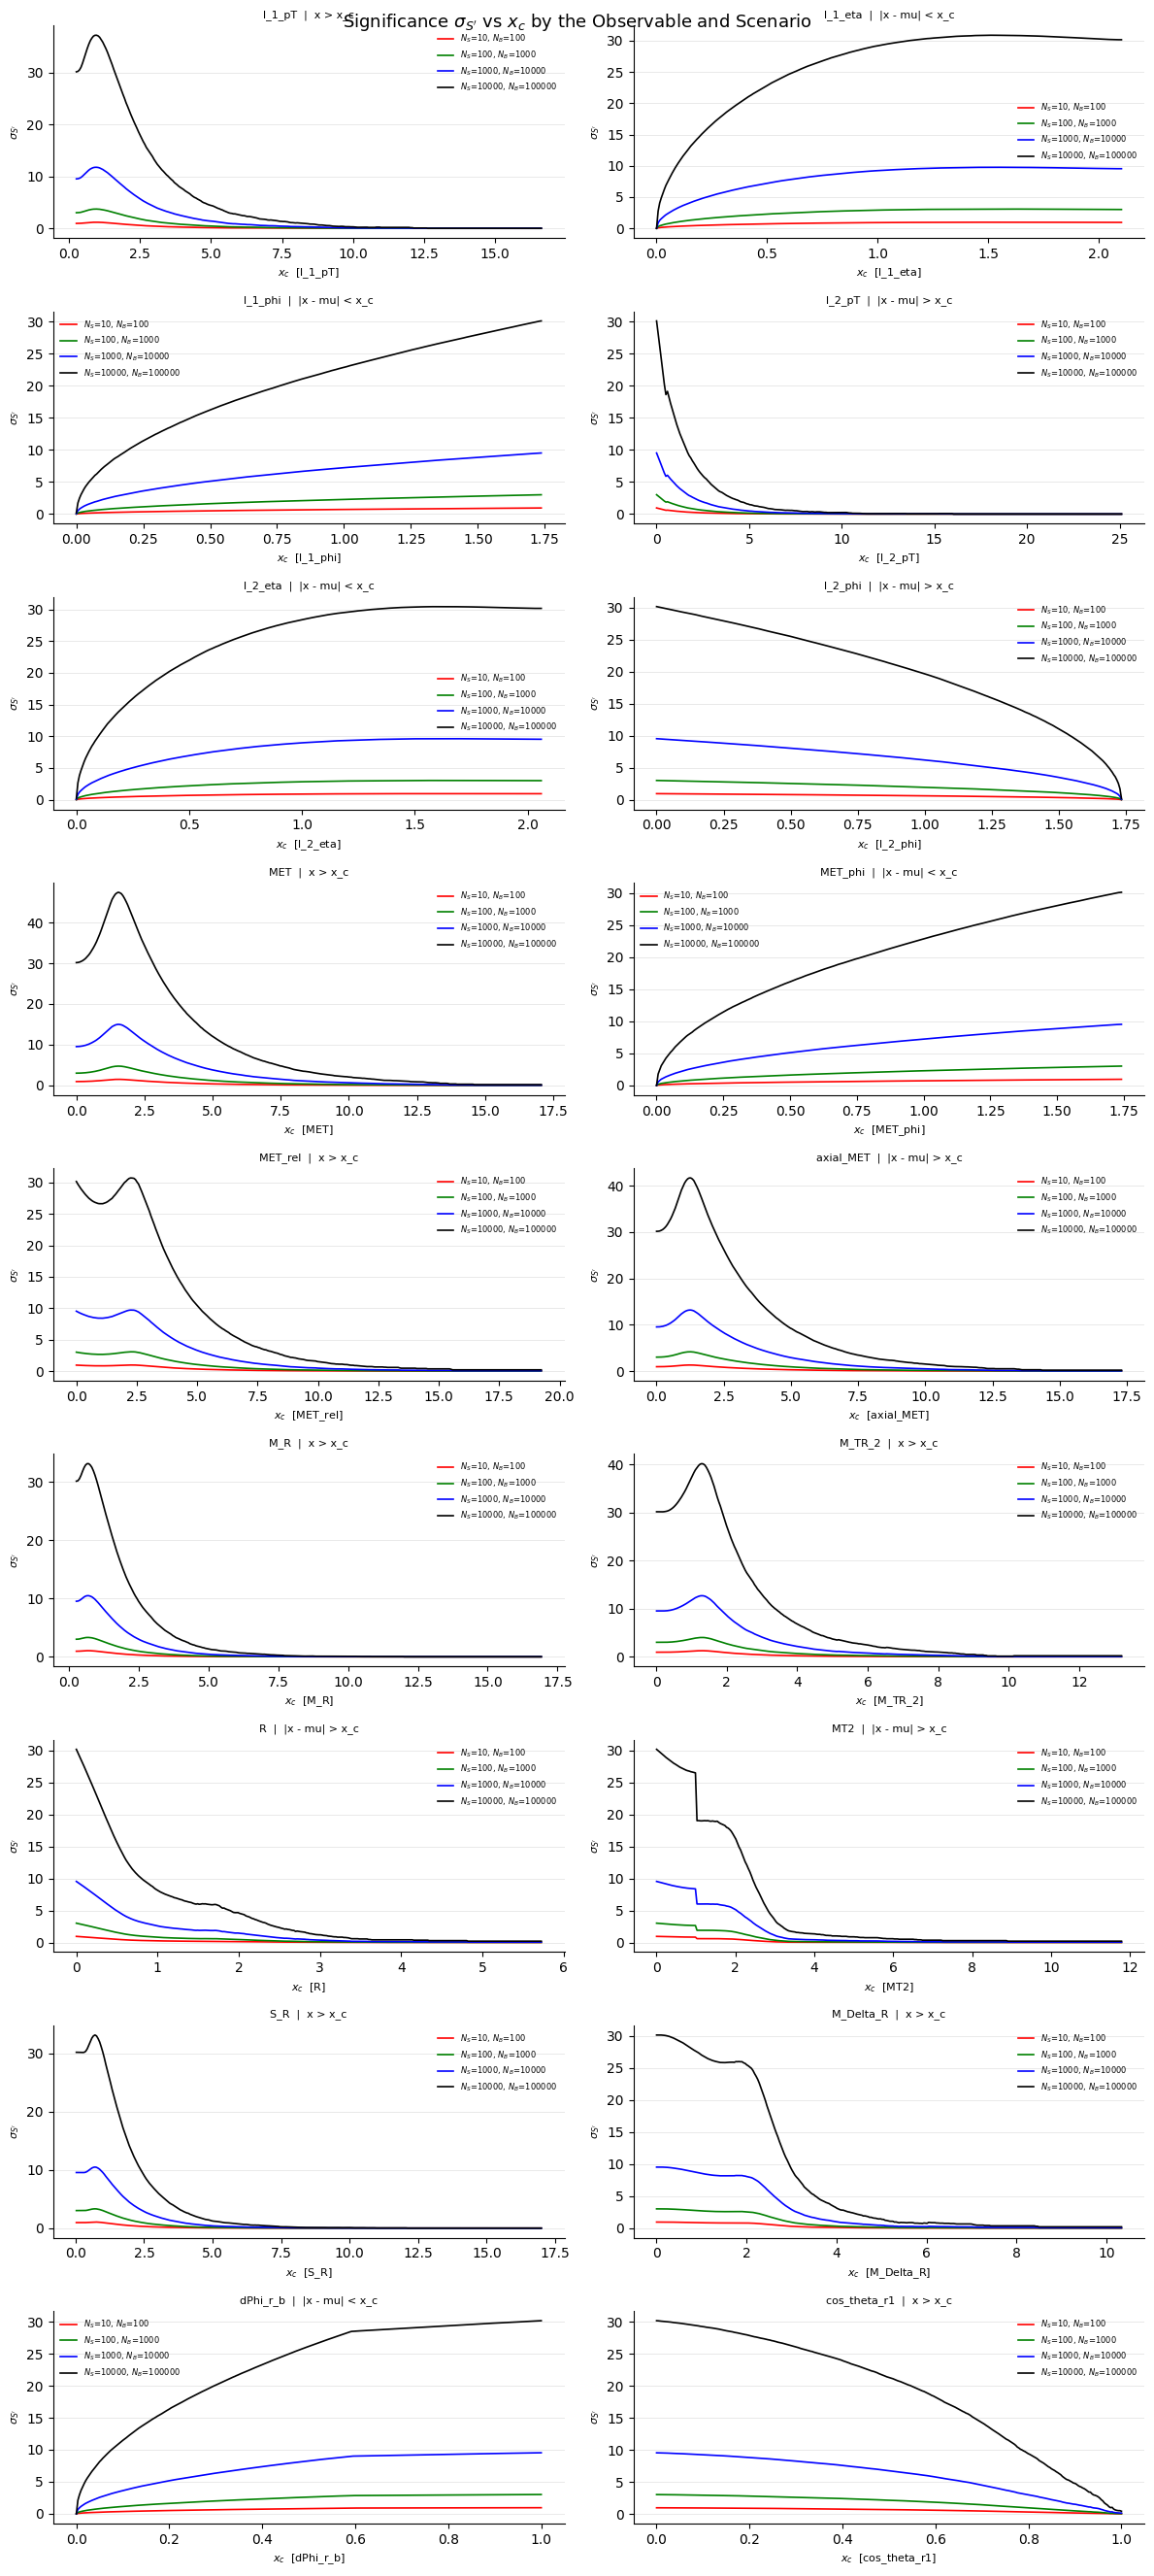

In [34]:
# Part 3

# this part of exercise 5 has us plot significance versus x_c for each observable under 4 signal/background scenarios

# Plot significance vs x_c for each observable under 4 signal/background scenarios.
#
# The significance and N'_S is defined above
# Essentially this tells us how detectable the signal is above the background fluctuation after a given selection.
#
# We reuse the TPR/FPR arrays from part 2, just scaled by different N_S and N_B values.
# Overlaying all 4 scenarios per panel shows how the optimal x_c shifts as the signal-to-background ratio changes.

# scenarios laid out in part 3
scenarios = [
    (10,    100),
    (100,   1000),
    (1000,  10000),
    (10000, 100000),
]
colors = ["red", "green", "blue", "black"]

fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 3))
axes = axes.flatten()

for ax, var in zip(axes, VarNames[1:]):
    cut_type, mu = cut_info[var]
    sa, ba = sig_arrs[var], bkg_arrs[var]

    # Build the same x_c sweep as in part 2 so the efficiency curves match
    if "mu" in cut_type:
        combined = np.abs(np.concatenate([sa, ba]) - mu)
    else:
        combined = np.concatenate([sa, ba])
    xc_vals = np.linspace(combined.min(), combined.max(), N_POINTS)

    # Compute efficiency once per variable - the same TPR/FPR applies to all scenarios, only the raw counts N_S and N_B change between them
    tpr = compute_efficiency(sa, cut_type, mu, xc_vals)
    fpr = compute_efficiency(ba, cut_type, mu, xc_vals)

    for (N_S, N_B), col in zip(scenarios, colors):
        # Scale efficiencies by the expected event counts for this scenario
        Ns_prime = tpr * N_S
        Nb_prime = fpr * N_B

        # Compute the significance, guarding against sqrt(0) at the extremes where both efficiencies collapse to zero
        denom = np.sqrt(Ns_prime + Nb_prime)
        with np.errstate(invalid="ignore", divide="ignore"):
            sig = np.where(denom > 0, Ns_prime / denom, 0.0)

        ax.plot(xc_vals, sig, color=col, lw=1.2,
                label=f"$N_S$={N_S}, $N_B$={N_B}")

    # simple graphing w matplotlib
    ax.set_xlabel(f"$x_c$  [{var}]", fontsize=8)
    ax.set_ylabel(r"$\sigma_{S'}$", fontsize=8)
    ax.set_title(f"{var}  |  {cut_type}", fontsize=8)
    ax.legend(fontsize=6, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, lw=0.4, alpha=0.5)

for ax in axes[len(VarNames[1:]):]:
    ax.set_visible(False)

fig.suptitle(r"Significance $\sigma_{S'}$ vs $x_c$ by the Observable and Scenario", fontsize=13)
fig.tight_layout()
plt.show()

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [35]:
# Rank all observables by their peak significance under the reference scenario so we can make an informed choice rather than guessing

ranking = []
for var in VarNames[1:]:
    xc_opt, sig_opt = find_optimal_xc(var, REFERENCE_NS, REFERENCE_NB)
    cut_type, _ = cut_info[var]
    ranking.append((var, cut_type, xc_opt, sig_opt))

# Sort by peak significance, highest first
ranking.sort(key=lambda x: x[3], reverse=True)

# Display the full ranked table so we can make an informed selection
rank_rows = [[var, cut_type, f"{xc:.4f}", f"{sig:.3f}"]
             for var, cut_type, xc, sig in ranking]
headers = ["Variable", "Cut Type", "Optimal x_c", f"Peak σ (NS={REFERENCE_NS}, NB={REFERENCE_NB})"]
display(HTML(tabulate(rank_rows, headers=headers, tablefmt="html")))

# this wasnt necessary, but if error occurs, run cells below for ex6 and run this again

Variable,Cut Type,Optimal x_c,"Peak σ (NS=100, NB=1000)"
MET,x > x_c,1.5407,4.741
axial_MET,|x - mu| > x_c,1.273,4.166
M_TR_2,x > x_c,1.2889,4.015
l_1_pT,x > x_c,0.9675,3.72
M_R,x > x_c,0.6571,3.316
S_R,x > x_c,0.7081,3.311
l_1_eta,|x - mu| < x_c,1.5124,3.087
MET_rel,x > x_c,2.2525,3.071
l_2_eta,|x - mu| < x_c,1.6331,3.043
M_Delta_R,x > x_c,0.0735,3.016


In [36]:
# Part 1

# Choose a subset of observables and find the optimal x_c for each one.
#
# In exercise 5 part 3 we plotted significance vs x_c for every variable across 4 scenarios. Rather than reading the peak x_c 
# off each plot by eye, we automate it here by running the same significance sweep and returning the x_c at the maximum.
#
# We use N_S=100, N_B=1000 as a reference scenario for finding optimal x_c values.

# imports
import numpy as np
from tabulate import tabulate
from IPython.display import HTML, display

# self explanatory references
REFERENCE_NS = 100
REFERENCE_NB = 1000
N_POINTS = 300

def find_optimal_xc(var, n_s, n_b, n_points=N_POINTS):
    # Sweeps x_c across the full data range for a given variable and returns the x_c value that maximises significance
    # under the given (n_s, n_b) scenario. This is essentially the same sweep performed in 5.3, but instead of
    # plotting the curve we just extract the peak value.

    # Pull the cut type and mu for this variable from the dictionary built in exercise part 1
    cut_type, mu = cut_info[var]

    # Pull the pre-extracted signal and background arrays from exercise 5 part 1
    sa, ba = sig_arrs[var], bkg_arrs[var]

    # Build the x_c sweep range.
    # For absolute-value cuts the sweep is over distances from mu, for threshold cuts it is over the raw observable values
    if "mu" in cut_type:
        combined = np.abs(np.concatenate([sa, ba]) - mu)
    else:
        combined = np.concatenate([sa, ba])
    xc_vals = np.linspace(combined.min(), combined.max(), n_points)

    # Compute signal and background efficiency across the sweep, reusing compute_efficiency from the last exercise
    tpr = compute_efficiency(sa, cut_type, mu, xc_vals)
    fpr = compute_efficiency(ba, cut_type, mu, xc_vals)

    # Scale efficiencies by expected counts to get N'_S and N'_B
    Ns_prime = tpr * n_s
    Nb_prime = fpr * n_b

    # Compute significance at each x_c, guarding against sqrt(0) at the extremes
    denom = np.sqrt(Ns_prime + Nb_prime)
    with np.errstate(invalid="ignore", divide="ignore"):
        sig = np.where(denom > 0, Ns_prime / denom, 0.0)

    # Find the index of the peak significance and return the corresponding x_c
    best_idx = np.argmax(sig)
    return xc_vals[best_idx], sig[best_idx]


# Selected based on the ranking table - these 6 show the highest peak significance with a clear gap separating them from the rest.
# Variables with x_c = 0 were excluded since their optimal cut is at the edge of the range, meaning no selection improves on taking all events.
selected_vars = ["MET", "axial_MET", "M_TR_2", "l_1_pT", "M_R", "S_R"]

# For each selected variable, find its optimal x_c under the reference scenario
# and store it in selected_cuts for use part 2 and 3
selected_cuts = {}
rows = []

for var in selected_vars:
    xc_opt, sig_opt = find_optimal_xc(var, REFERENCE_NS, REFERENCE_NB)

    # Store the optimal x_c - this is what the cut-flow in part 2 will use
    selected_cuts[var] = xc_opt

    # Also grab the cut type for display in the summary table
    cut_type, _ = cut_info[var]
    rows.append([var, cut_type, f"{xc_opt:.4f}", f"{sig_opt:.3f}"])

# Display the summary table so we have a clear record of the choices going into the cut-flow in the next part
headers = ["Variable", "Cut Type", "Optimal x_c", f"Peak σ (NS={REFERENCE_NS}, NB={REFERENCE_NB})"]
display(HTML(tabulate(rows, headers=headers, tablefmt="html")))

Variable,Cut Type,Optimal x_c,"Peak σ (NS=100, NB=1000)"
MET,x > x_c,1.5407,4.741
axial_MET,|x - mu| > x_c,1.273,4.166
M_TR_2,x > x_c,1.2889,4.015
l_1_pT,x > x_c,0.9675,3.72
M_R,x > x_c,0.6571,3.316
S_R,x > x_c,0.7081,3.311


In [37]:
# Part 2

# This will build a cut-flow table for each scenario.
#
# In Exercise 5, every variable was tested independently on the full dataset. Here we apply cuts one after another - each cut only sees the events that
# survived the previous cut. Think of it like a series of filters, where each filter is applied to whatever came out of the last one.
#
# After each cut we record the following
# eps_S - fraction of original signal events still surviving
# eps_B - fraction of original background events still surviving
# N'_S - ow many signal events we expect to have left
# N'_B - how many background events we expect to have left
# sigma - significance at this point in the flow

# scenarios, same as in ex5
scenarios = [
    (10,    100),
    (100,   1000),
    (1000,  10000),
    (10000, 100000),
]

def apply_cut_mask(arr, cut_type, mu, xc):
    # Given an array of values, returns True/False for each event depending on whether it passes the cut or not
    if cut_type == "x > x_c":
        return arr > xc
    elif cut_type == "x < x_c":
        return arr < xc
    elif cut_type == "|x - mu| < x_c":
        return np.abs(arr - mu) < xc
    else:
        return np.abs(arr - mu) > xc

def run_cutflow(selected_vars, selected_cuts, n_s, n_b):
    # Applies each cut in sequence and records the results after every step.

    # Start with every event surviving - True means the event is still in
    sig_mask = np.ones(len(df_sig), dtype=bool)
    bkg_mask = np.ones(len(df_bkg), dtype=bool)

    # Remember the original sample sizes so we can track what fraction
    # of the original data is still surviving after each cut
    n_sig_total = len(df_sig)
    n_bkg_total = len(df_bkg)

    rows = []
    for var in selected_vars:
        cut_type, mu = cut_info[var]
        xc = selected_cuts[var]

        # Only look at events that are still alive at this point in the flow. This is what makes it sequential - we are not going back to the
        # full dataset for each new cut
        sig_vals = df_sig[var].to_numpy()[sig_mask]
        bkg_vals = df_bkg[var].to_numpy()[bkg_mask]

        # Check which of those surviving events pass this cut
        sig_pass = apply_cut_mask(sig_vals, cut_type, mu, xc)
        bkg_pass = apply_cut_mask(bkg_vals, cut_type, mu, xc)

        # Update the survival masks.
        # sig_mask[sig_mask] = sig_pass works by writing the new pass/fail results back into only the positions that were already True,
        # so the mask stays the same length as the original dataframe
        sig_mask[sig_mask] = sig_pass
        bkg_mask[bkg_mask] = bkg_pass

        # What fraction of the original sample is still surviving
        eps_s = sig_mask.sum() / n_sig_total
        eps_b = bkg_mask.sum() / n_bkg_total

        # Scale those fractions by the expected event counts for this scenario
        ns_prime = eps_s * n_s
        nb_prime = eps_b * n_b

        # Compute significance, avoiding division by zero if both go to zero
        denom = np.sqrt(ns_prime + nb_prime)
        sigma = ns_prime / denom if denom > 0 else 0.0

        rows.append([
            var, cut_type, f"{xc:.4f}",
            f"{eps_s:.4f}", f"{eps_b:.4f}",
            f"{ns_prime:.2f}", f"{nb_prime:.2f}", f"{sigma:.3f}"
        ])

    return rows

headers = ["Variable", "Cut Type", "x_c", "ε_S", "ε_B", "N'_S", "N'_B", "σ"]

# Print the cut-flow table for each scenario.
# Watch whether sigma goes up or down with each successive cut - if it starts dropping, that variable is no longer helping after
# the previous cuts have already been applied
for (n_s, n_b) in scenarios:
    print(f"\nScenario: N_S = {n_s},  N_B = {n_b}")
    rows = run_cutflow(selected_vars, selected_cuts, n_s, n_b)
    display(HTML(tabulate(rows, headers=headers, tablefmt="html")))


Scenario: N_S = 10,  N_B = 100


Variable,Cut Type,x_c,ε_S,ε_B,N'_S,N'_B,σ
MET,x > x_c,1.5407,0.3251,0.0145,3.25,1.45,1.499
axial_MET,|x - mu| > x_c,1.273,0.2177,0.0075,2.18,0.75,1.272
M_TR_2,x > x_c,1.2889,0.1554,0.0065,1.55,0.65,1.046
l_1_pT,x > x_c,0.9675,0.1264,0.0045,1.26,0.45,0.965
M_R,x > x_c,0.6571,0.1264,0.0045,1.26,0.45,0.964
S_R,x > x_c,0.7081,0.1263,0.0045,1.26,0.45,0.964



Scenario: N_S = 100,  N_B = 1000


Variable,Cut Type,x_c,ε_S,ε_B,N'_S,N'_B,σ
MET,x > x_c,1.5407,0.3251,0.0145,32.51,14.51,4.741
axial_MET,|x - mu| > x_c,1.273,0.2177,0.0075,21.77,7.53,4.022
M_TR_2,x > x_c,1.2889,0.1554,0.0065,15.54,6.53,3.308
l_1_pT,x > x_c,0.9675,0.1264,0.0045,12.64,4.54,3.05
M_R,x > x_c,0.6571,0.1264,0.0045,12.64,4.54,3.05
S_R,x > x_c,0.7081,0.1263,0.0045,12.63,4.54,3.049



Scenario: N_S = 1000,  N_B = 10000


Variable,Cut Type,x_c,ε_S,ε_B,N'_S,N'_B,σ
MET,x > x_c,1.5407,0.3251,0.0145,325.12,145.11,14.993
axial_MET,|x - mu| > x_c,1.273,0.2177,0.0075,217.7,75.31,12.718
M_TR_2,x > x_c,1.2889,0.1554,0.0065,155.38,65.26,10.46
l_1_pT,x > x_c,0.9675,0.1264,0.0045,126.43,45.39,9.645
M_R,x > x_c,0.6571,0.1264,0.0045,126.41,45.39,9.644
S_R,x > x_c,0.7081,0.1263,0.0045,126.35,45.39,9.641



Scenario: N_S = 10000,  N_B = 100000


Variable,Cut Type,x_c,ε_S,ε_B,N'_S,N'_B,σ
MET,x > x_c,1.5407,0.3251,0.0145,3251.24,1451.13,47.412
axial_MET,|x - mu| > x_c,1.273,0.2177,0.0075,2177.02,753.08,40.218
M_TR_2,x > x_c,1.2889,0.1554,0.0065,1553.8,652.62,33.079
l_1_pT,x > x_c,0.9675,0.1264,0.0045,1264.32,453.92,30.501
M_R,x > x_c,0.6571,0.1264,0.0045,1264.11,453.92,30.498
S_R,x > x_c,0.7081,0.1263,0.0045,1263.45,453.92,30.488


Scenario: N_S=1000, N_B=10000  |  Variables: M_R and M_TR_2

Fixed x_c — order: M_R → M_TR_2


Variable,Cut Type,x_c,ε_S,ε_B,N'_S,N'_B,σ
M_R,x > x_c,0.6571,0.8266,0.5387,826.59,5387.16,10.486
M_TR_2,x > x_c,1.2889,0.3839,0.0568,383.89,567.82,12.444



Fixed x_c — order: M_TR_2 → M_R


Variable,Cut Type,x_c,ε_S,ε_B,N'_S,N'_B,σ
M_TR_2,x > x_c,1.2889,0.4027,0.0603,402.75,603.31,12.698
M_R,x > x_c,0.6571,0.3839,0.0568,383.89,567.82,12.444



Re-optimised: M_R first, then re-optimise M_TR_2
  New x_c for M_TR_2: 1.2908   Peak σ: 12.445

Re-optimised: M_TR_2 first, then re-optimise M_R
  New x_c for M_R: 0.2820   Peak σ: 12.698


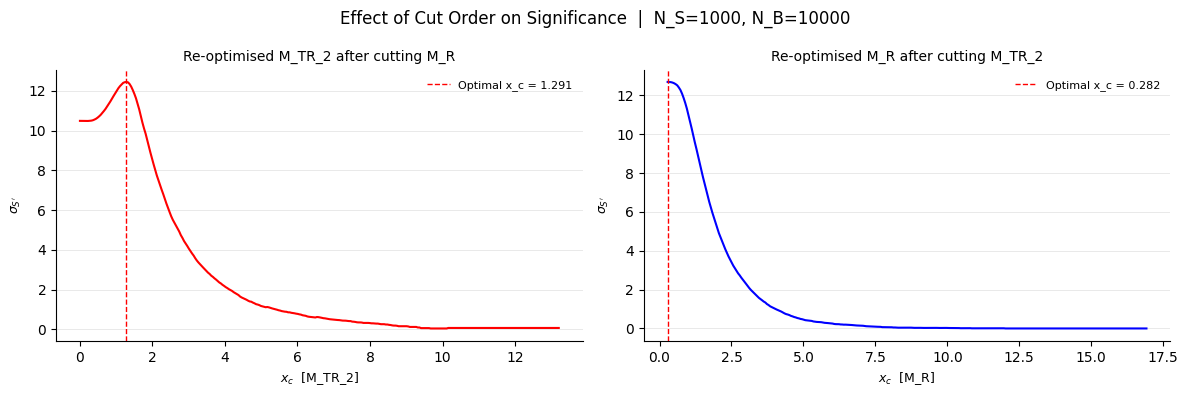

In [38]:
# Part 3

# Here we want to investigatre how variable correlation affects cut optimisation order.
#
# In ex5 p3, the optimal x_c for each variable was found by optimising on the full dataset independently. This works fine if variables are uncorrelated,
# but if two variables share information, cutting on one changes the shape of the other's distribution. The events that survive the first cut are not
# a random sample of the full dataset, they are a biased subset, and the second variable may look quite different in that subset than it did before.
# This means the x_c that was optimal for the second variable on the full sample may no longer be the best choice after the first cut has been applied.
#
# We test this by taking two correlated variables -> M_R and M_TR_2, which showed high correlation in Exercise 4 - applying them in both possible
# orders, and re-optimising the second variables x_c on the surviving events rather than on the full dataset. Comparing the two orderings then shows
# whether the correlation is materially affecting the result.

CORR_VAR_A = "M_R"
CORR_VAR_B = "M_TR_2"

# Scenario 3 for this illustration, its large enough counts that the significance values are meaningful and differences between orderings show clearly
REF_NS, REF_NB = 1000, 10000

def optimise_after_cut(var_first, var_second, n_s, n_b):
    # Applies the optimal cut on var_first, then sweeps x_c for var_second over only the events that survived var_first cut.
    # The return values are the re-optimised x_c, its peak significnce, the full x_c sweep array, and the full significance curve,the last
    # two are returned so we can plot the curve in full rather than just the peak.

    # Pull cut strategy and midpoint for both variables from the ex5 p1 dictionary
    cut_type_1, mu_1 = cut_info[var_first]
    cut_type_2, mu_2 = cut_info[var_second]

    # Pull the x_c that was found to be optimal in ex6 p1 for the first variable
    xc_1 = selected_cuts[var_first]

    # Apply the first cut to the full signal and background arrays, producing a True/False mask for every event in the original dataset
    sig_pass_1 = apply_cut_mask(sig_arrs[var_first], cut_type_1, mu_1, xc_1)
    bkg_pass_1 = apply_cut_mask(bkg_arrs[var_first], cut_type_1, mu_1, xc_1)

    # Record what fraction of events survived the first cut. .mean() on a boolean array gives the fraction of True values,
    # which is equivalent to n_passing / n_total
    eps_s_1 = sig_pass_1.mean()
    eps_b_1 = bkg_pass_1.mean()

    # Extract the second variable's values for only the surviving events. This is the reduced sample that the re-optimisation will run on.
    # It may have a different dist than the full dataset if the two variables are correlated
    sa2 = sig_arrs[var_second][sig_pass_1]
    ba2 = bkg_arrs[var_second][bkg_pass_1]

    # Build the x_c sweep over the reduced sample's range, not the full dataset.
    # The survivors may occupy a narrower range, so this keeps the resolution useful
    if "mu" in cut_type_2:
        combined = np.abs(np.concatenate([sa2, ba2]) - mu_2)
    else:
        combined = np.concatenate([sa2, ba2])
    xc_vals = np.linspace(combined.min(), combined.max(), N_POINTS)

    # Compute TPR and FPR for var_second on the reduced sample
    tpr2 = compute_efficiency(sa2, cut_type_2, mu_2, xc_vals)
    fpr2 = compute_efficiency(ba2, cut_type_2, mu_2, xc_vals)

    # Chain both cuts together, overall efficiency is first cut survival
    # fraction multiplied by the second cut's efficiency on those survivors
    eps_s_final = eps_s_1 * tpr2
    eps_b_final = eps_b_1 * fpr2

    # Compute significance across the sweep, guarding against division by zero
    Ns_f = eps_s_final * n_s
    Nb_f = eps_b_final * n_b
    denom = np.sqrt(Ns_f + Nb_f)
    with np.errstate(invalid="ignore", divide="ignore"):
        sig_curve = np.where(denom > 0, Ns_f / denom, 0.0)

    # Return peak x_c, peak significance, and the full curve for plotting
    best_idx = np.argmax(sig_curve)
    return xc_vals[best_idx], sig_curve[best_idx], xc_vals, sig_curve


# Run in both orderings - A then B, and B then A
xc_b_reopt, sig_AB, xc_b_vals, sig_AB_curve = optimise_after_cut(CORR_VAR_A, CORR_VAR_B, REF_NS, REF_NB)
xc_a_reopt, sig_BA, xc_a_vals, sig_BA_curve = optimise_after_cut(CORR_VAR_B, CORR_VAR_A, REF_NS, REF_NB)

# Run both orderings with fixed x_c values from ex6 p1 as a baseline comparison.
# If re-optimised sigma is higher, the correlation was genuinely causing the fixed x_c to underperform
# This will be noticeable later ^^^
rows_fixed_AB = run_cutflow([CORR_VAR_A, CORR_VAR_B], selected_cuts, REF_NS, REF_NB)
rows_fixed_BA = run_cutflow([CORR_VAR_B, CORR_VAR_A], selected_cuts, REF_NS, REF_NB)

print(f"Scenario: N_S={REF_NS}, N_B={REF_NB}  |  Variables: {CORR_VAR_A} and {CORR_VAR_B}\n")

print(f"Fixed x_c — order: {CORR_VAR_A} → {CORR_VAR_B}")
display(HTML(tabulate(rows_fixed_AB, headers=headers, tablefmt="html")))

print(f"\nFixed x_c — order: {CORR_VAR_B} → {CORR_VAR_A}")
display(HTML(tabulate(rows_fixed_BA, headers=headers, tablefmt="html")))

print(f"\nRe-optimised: {CORR_VAR_A} first, then re-optimise {CORR_VAR_B}")
print(f"  New x_c for {CORR_VAR_B}: {xc_b_reopt:.4f}   Peak σ: {sig_AB:.3f}")

print(f"\nRe-optimised: {CORR_VAR_B} first, then re-optimise {CORR_VAR_A}")
print(f"  New x_c for {CORR_VAR_A}: {xc_a_reopt:.4f}   Peak σ: {sig_BA:.3f}")

# Plot the re-optimised significance curve for each ordering. If the curve shape or peak differs noticeably from the ex5 p3 plot for the
# same variable, that is direct evidence of the correlation effect
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left - M_R cut first, M_TR_2 re-optimised on survivors
axes[0].plot(xc_b_vals, sig_AB_curve, color="red", lw=1.5)
axes[0].axvline(xc_b_reopt, color="red", lw=1, ls="--",
                label=f"Optimal x_c = {xc_b_reopt:.3f}")
axes[0].set_title(f"Re-optimised {CORR_VAR_B} after cutting {CORR_VAR_A}", fontsize=10)
axes[0].set_xlabel(f"$x_c$  [{CORR_VAR_B}]", fontsize=9)
axes[0].set_ylabel(r"$\sigma_{{S'}}$", fontsize=9)
axes[0].legend(fontsize=8, frameon=False)

# Right - M_TR_2 cut first, M_R re-optimised on survivors
axes[1].plot(xc_a_vals, sig_BA_curve, color="blue", lw=1.5)
axes[1].axvline(xc_a_reopt, color="red", lw=1, ls="--",
                label=f"Optimal x_c = {xc_a_reopt:.3f}")
axes[1].set_title(f"Re-optimised {CORR_VAR_A} after cutting {CORR_VAR_B}", fontsize=10)
axes[1].set_xlabel(f"$x_c$  [{CORR_VAR_A}]", fontsize=9)
axes[1].set_ylabel(r"$\sigma_{{S'}}$", fontsize=9)
axes[1].legend(fontsize=8, frameon=False)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, lw=0.4, alpha=0.5)

fig.suptitle(f"Effect of Cut Order on Significance  |  N_S={REF_NS}, N_B={REF_NB}", fontsize=12)
fig.tight_layout()
plt.show()

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



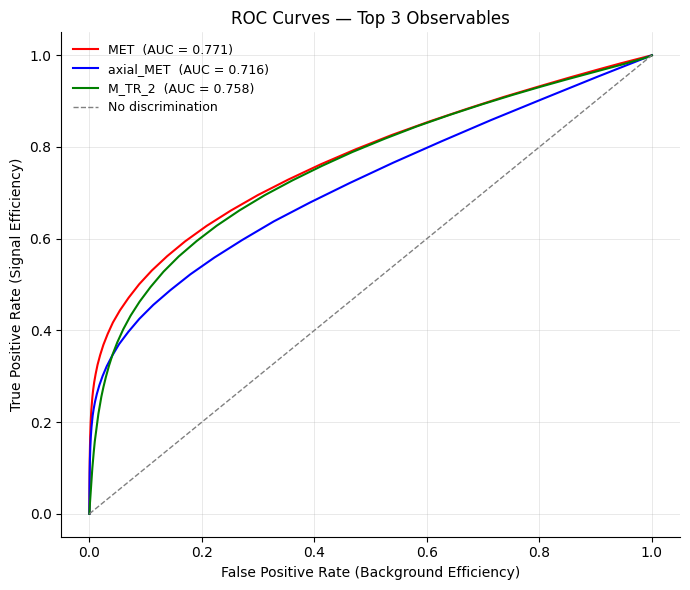

In [39]:
# Part 1 

# Plot ROC curves for the top 3 observables with AUC (are under curve) reported in the legend. A perfect classifier hugs the top-left corner,
# a useless one follows the diagonal. AUC is computed using the trapezoid rule from Lecture 17.

import matplotlib.pyplot as plt
import numpy as np

# Top 3 from the ex5 significance ranking
top_vars = ["MET", "axial_MET", "M_TR_2"]
colors = ["red", "blue", "green"]

def compute_auc(tpr, fpr):
    # Trapezoid rule from Lecture 17 -> more accurate than simple rectangles.
    # Lecture 17 first computes AUC with a rectangle loop, then improves it to trapezoids using: (FPR[k] - FPR[k+1]) * (TPR[k] + TPR[k+1]) / 2
    # This is that same approach vectorised with numpy instead of a loop
    n = len(fpr)
    return np.sum((fpr[:n-1] - fpr[1:]) * (tpr[:n-1] + tpr[1:]) / 2)

fig, ax = plt.subplots(figsize=(7, 6))

for var, col in zip(top_vars, colors):
    # Pull cut strategy and pre-extracted arrays for this variable
    cut_type, mu = cut_info[var]
    sa, ba = sig_arrs[var], bkg_arrs[var]

    # Same x_c sweep setup as ex5 part 2
    if "mu" in cut_type:
        combined = np.abs(np.concatenate([sa, ba]) - mu)
    else:
        combined = np.concatenate([sa, ba])
    xc_vals = np.linspace(combined.min(), combined.max(), N_POINTS)

    # Reuse compute_efficiency from ex5 part 2
    tpr = compute_efficiency(sa, cut_type, mu, xc_vals)
    fpr = compute_efficiency(ba, cut_type, mu, xc_vals)

    # Compute AUC and include it in the legend label
    auc = compute_auc(tpr, fpr)
    ax.plot(fpr, tpr, color=col, lw=1.5, label=f"{var}  (AUC = {auc:.3f})")

# Diagonal reference line from Lecture 17 --- plt.plot([0,1],[0,1]) --- represents a classifier with zero discriminating power
ax.plot([0, 1], [0, 1], color="grey", lw=1, ls="--", label="No discrimination")

ax.set_xlabel("False Positive Rate (Background Efficiency)", fontsize=10)
ax.set_ylabel("True Positive Rate (Signal Efficiency)", fontsize=10)
ax.set_title("ROC Curves — Top 3 Observables", fontsize=12)
ax.legend(fontsize=9, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, lw=0.4, alpha=0.5)

fig.tight_layout()
plt.show()

In [40]:
# Part 2 

# Reusable ROC curve function so we are not rewriting the same plotting code for every new set of observables in part 3 an d 4
#
# Lecture 17 builds toward this same idea, it starts with hardcoded TPR/FPR for M_TR_2, then generalises into compare_significance() which accepts any
# observable as an argument. We follow the same pattern here for ROC curves.

def plot_roc_curves(var_labels, sig_arrays, bkg_arrays, title="ROC Curves"):
    # var_labels - legend label for each curve
    # sig_arrays - list of signal numpy arrays, one per label
    # bkg_arrays - list of background numpy arrays, one per label
    # Arrays can be from the full dataset or post-cut survivors, which is what makes this flexible enough for 3 and 4

    # Evenly spaced colours so curves stay distinct for any number of variables
    cmap   = plt.cm.tab10
    colors = [cmap(i / max(len(var_labels) - 1, 1)) for i in range(len(var_labels))]

    fig, ax = plt.subplots(figsize=(7, 6))

    for label, sa, ba, col in zip(var_labels, sig_arrays, bkg_arrays, colors):

        # Sweep x_c over the combined range of both arrays
        xc_vals = np.linspace(
            min(sa.min(), ba.min()),
            max(sa.max(), ba.max()),
            N_POINTS
            
        )

        # Simple x > x_c threshold — same logic as compute_rate_1 in Lecture 17, which uses
        # cumulative sum on a reversed histogram to get the fraction above x_c. Here we use searchsorted on a sorted array for the same result but faster
        tpr = 1.0 - np.searchsorted(np.sort(sa), xc_vals, side="left") / len(sa)
        fpr = 1.0 - np.searchsorted(np.sort(ba), xc_vals, side="left") / len(ba)

        # AUC summarises the whole curve into one number — closer to 1.0 is better
        auc = compute_auc(tpr, fpr)
        ax.plot(fpr, tpr, color=col, lw=1.5, label=f"{label}  (AUC = {auc:.3f})")

    # Diagonal reference line -> same as Lecture 17's plt.plot([0,1],[0,1])
    ax.plot([0, 1], [0, 1], color="grey", lw=1, ls="--", label="No discrimination")
    ax.set_xlabel("False Positive Rate (Background Efficiency)", fontsize=10)
    ax.set_ylabel("True Positive Rate (Signal Efficiency)", fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, lw=0.4, alpha=0.5)

    fig.tight_layout()
    plt.show()

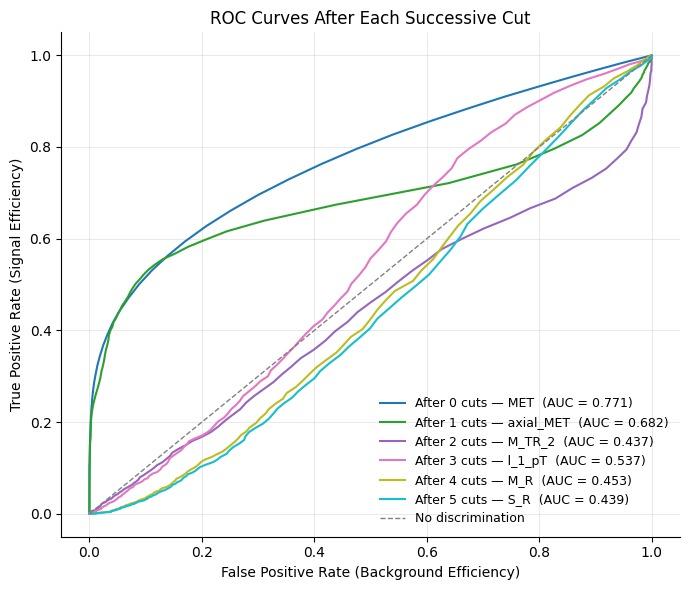

In [41]:
# Part 3

# We plot the ROC curve after each successive cut from the ex6 cut-flow.
# As cuts are applied the surviving sample gets cleaner, so the ROC curve for the next variable should shift toward the top-left corner.
#
# Lecture 16 demonstrates this same idea in cells 61thru67 - it applies a cut on M_TR_2, creates df_sig_1 and df_bkg_1 from the survivors, then calls
# compare_significance again on the reduced sample to show how the result changes. Here we do the same but track it across every step of the flow and show
# the effect through ROC curves rather than significance plots.

# Same mask initialisation as run_cutflow in ex6
sig_mask_flow = np.ones(len(df_sig), dtype=bool)
bkg_mask_flow = np.ones(len(df_bkg), dtype=bool)

# Storage for the label and arrays at each step
roc_labels   = []
roc_sig_arrs = []
roc_bkg_arrs = []

for i, var in enumerate(selected_vars):
    cut_type, mu = cut_info[var]
    xc = selected_cuts[var]

    # Only look at events still surviving at this point in the flow
    sig_vals = df_sig[var].to_numpy()[sig_mask_flow]
    bkg_vals = df_bkg[var].to_numpy()[bkg_mask_flow]

    # Store before applying the cut so the ROC reflects this variable's
    # discriminating power on the sample that reached this point
    roc_labels.append(f"After {i} cuts — {var}")
    roc_sig_arrs.append(sig_vals)
    roc_bkg_arrs.append(bkg_vals)

    # Apply cut and update masks for the next step
    sig_pass = apply_cut_mask(sig_vals, cut_type, mu, xc)
    bkg_pass = apply_cut_mask(bkg_vals, cut_type, mu, xc)
    sig_mask_flow[sig_mask_flow] = sig_pass
    bkg_mask_flow[bkg_mask_flow] = bkg_pass
    
# Pass all steps into the function from p2 to produce the overlaid figure
plot_roc_curves(
    roc_labels, roc_sig_arrs, roc_bkg_arrs,
    title="ROC Curves After Each Successive Cut"
)

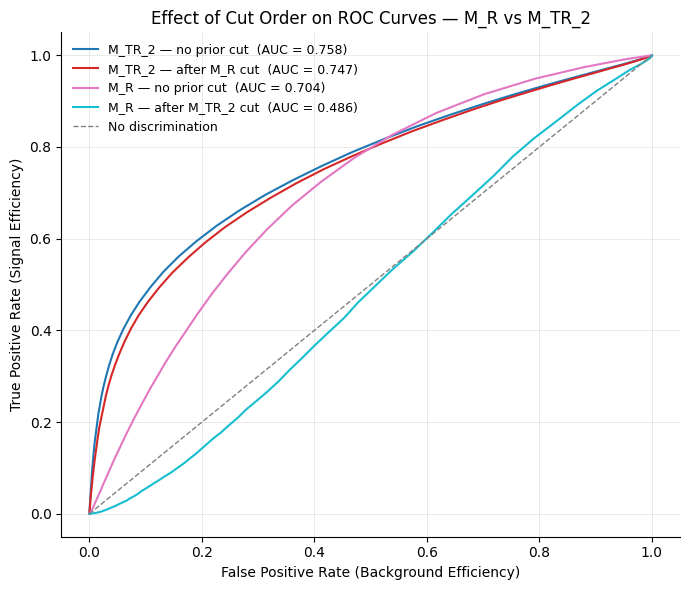

In [42]:
# Part 4

# Here weshow how cut order affects the ROC curve for correlated variables.
# We plot each variable's ROC both before and after its partner has been cut first,
# if the AUC changes, the correlation is affecting discriminating power.
#
# Lecture 16 demonstrates this exact effect in cells 73 through 75 - it computes TPR_1 * TPR_2 (assuming independence) and compares it to the actual
# TPR_1_2 from np.logical_and, showing they differ when variables are correlated.
# Here we show the same effect visually through the shift in ROC curves.

# Apply M_R cut, then extract M_TR_2 values for survivors
cut_type_a, mu_a = cut_info[CORR_VAR_A]
sig_pass_a = apply_cut_mask(sig_arrs[CORR_VAR_A], cut_type_a, mu_a, selected_cuts[CORR_VAR_A])
bkg_pass_a = apply_cut_mask(bkg_arrs[CORR_VAR_A], cut_type_a, mu_a, selected_cuts[CORR_VAR_A])

# Extract M_TR_2 values for only the events that survived the M_R cut
sa_after_A = sig_arrs[CORR_VAR_B][sig_pass_a]
ba_after_A = bkg_arrs[CORR_VAR_B][bkg_pass_a]

# Apply M_TR_2 cut, then extract M_R values for survivors
cut_type_b, mu_b = cut_info[CORR_VAR_B]
sig_pass_b = apply_cut_mask(sig_arrs[CORR_VAR_B], cut_type_b, mu_b, selected_cuts[CORR_VAR_B])
bkg_pass_b = apply_cut_mask(bkg_arrs[CORR_VAR_B], cut_type_b, mu_b, selected_cuts[CORR_VAR_B])

# Extract M_R values for only the events that survived the M_TR_2 cut
sa_after_B = sig_arrs[CORR_VAR_A][sig_pass_b]
ba_after_B = bkg_arrs[CORR_VAR_A][bkg_pass_b]

# Four curves - baseline and post-cut for each variable
labels = [
    f"{CORR_VAR_B} — no prior cut",
    f"{CORR_VAR_B} — after {CORR_VAR_A} cut",
    f"{CORR_VAR_A} — no prior cut",
    f"{CORR_VAR_A} — after {CORR_VAR_B} cut",
]

# Match signal and background arrays to each label
sig_arrs_roc = [sig_arrs[CORR_VAR_B], sa_after_A, sig_arrs[CORR_VAR_A], sa_after_B]
bkg_arrs_roc = [bkg_arrs[CORR_VAR_B], ba_after_A, bkg_arrs[CORR_VAR_A], ba_after_B]

# Any AUC shift between the baseline and post-cut curve confirms the
# correlation is changing the variable's discriminating power
plot_roc_curves(
    labels, sig_arrs_roc, bkg_arrs_roc,
    title=f"Effect of Cut Order on ROC Curves — {CORR_VAR_A} vs {CORR_VAR_B}"
)

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.2

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.3

Draw the ROC curve for $F_n$. 

### Exercise 8.4

What is the maximal significance you can obtain in the scenarios in exercise 5? 

In [43]:
#Part 1

# Computing the between-class (S_B) and within-class (S_W) covariance matrices.
#
# Rather than separating signal from background by a single variable cut, a linear discriminant finds the best linear combination of all variables
# at once. S_B captures how far apart the signal and background means are, S_W captures how spread out each class is internally. Together they are
# used to find the optimal weight vector in Part 2.
#
# Lecture 17 walks through this exact computation step by step - we follow the same approach using np.matrix to
# handle the outer products correctly.

import numpy as np

# Drop the signal label column - we don't want the ground truth included
# in the feature matrix, as noted in Lecture 17 cell 43
df_sig_0 = df_sig.drop("signal", axis=1)
df_bkg_0 = df_bkg.drop("signal", axis=1)

# Compute the mean feature vector for signal and background separately. axis=0 averages over all events, giving one mean value per variable
m_s = np.mean(df_sig_0, axis=0)
m_b = np.mean(df_bkg_0, axis=0)

# delta is the difference between class means
# a column vector of shape (18, 1). np.matrix().transpose() is needed here because numpy arrays are 1D by default,
# so delta * delta.T would be a scalar rather than the 18x18 outer product we want. This matches Lecture 17 cell 55 exactly
delta = np.matrix(m_s - m_b).transpose()

# S_B = delta * delta^T - outer product giving an 18x18 between-class matrix. Large values mean the class means are far apart in that pair of dimensions
S_B = delta * delta.transpose()

print("S_B shape:", S_B.shape)

# For S_W we need (x_n - m_i) for every event n in each class i.
# Subtracting m_s from df_sig_0 broadcasts across all rows — each event's features have the class mean subtracted. Transposing gives shape (18, n_events)
delta_s = np.matrix(df_sig_0 - m_s).transpose()
delta_b = np.matrix(df_bkg_0 - m_b).transpose()

# S_W = sum of outer products for each class.

# delta_s * delta_s.T sums the outer product over all signal events at once,
# equivalent to the double sum in the formula but computed in one matrix multiply.
# Same approach used in Lecture 17 cells 65 and 68
S_W_s = delta_s * delta_s.transpose()
S_W_b = delta_b * delta_b.transpose()

# Total within-class scatter is the sum of both classes
S_W = S_W_s + S_W_b

print("S_W shape:", S_W.shape)

S_B shape: (18, 18)
S_W shape: (18, 18)


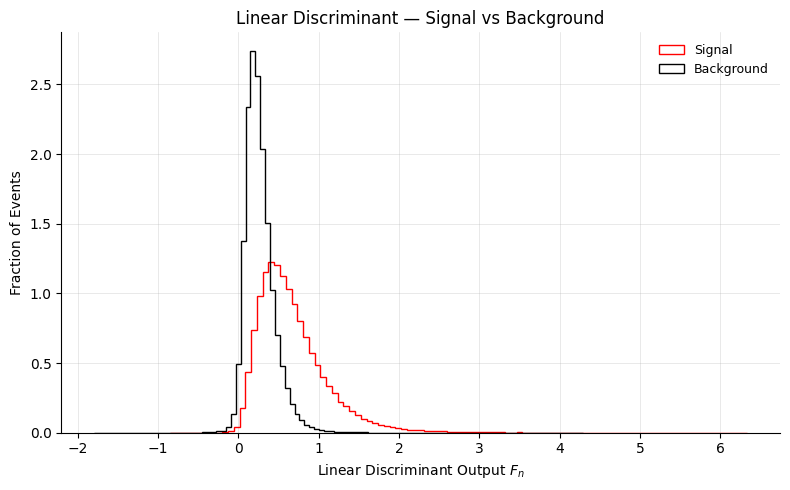

In [44]:
# Part 2

# Computing the linear discriminant weight vector w and plot the output distributions.
#
# the given eq gives the direction in feature space that maximises separation between the two classes relative to their internal spread.
# Projecting each event onto w gives a single score F_n — signal and background should cluster at different values.
#
# Lecture 17 cells 73-80 implement this

# Invert S_W — if S_W is singular this will raise an error, which would indicate two or more variables are perfectly correlated
S_W_inv = np.linalg.inv(S_W)

# w = S_W^{-1} * delta — the optimal linear coefficients.
# Lecture 17 uses (m_b - m_s) so that higher F_n values correspond to signal
w = S_W_inv * np.matrix(m_b - m_s).transpose()

# Normalise w so weights sum to 1 - keeps output scores on a reasonable scale
# without changing the discriminant's behaviour, as shown in Lecture 17 cell 78
w_1 = w / sum(w)

# Project every event onto w to get its discriminant score F_n.
# np.matrix multiplication handles the dot product across all events at once,
# giving one score per event — shape (n_events, 1)
output_s = np.matrix(df_sig_0) * w_1
output_b = np.matrix(df_bkg_0) * w_1

# Flatten from (n, 1) matrix to 1D array for plotting
output_s = np.array(output_s).flatten()
output_b = np.array(output_b).flatten()

# Plot the F_n distributions — good separation here means the discriminant
# is successfully combining the variables into a useful single score
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(output_s, bins=100, histtype="step", color="red",   density=True, label="Signal")
ax.hist(output_b, bins=100, histtype="step", color="black", density=True, label="Background")
ax.set_xlabel("Linear Discriminant Output $F_n$", fontsize=10)
ax.set_ylabel("Fraction of Events", fontsize=10)
ax.set_title("Linear Discriminant — Signal vs Background", fontsize=12)
ax.legend(fontsize=9, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, lw=0.4, alpha=0.5)

fig.tight_layout()
plt.show()

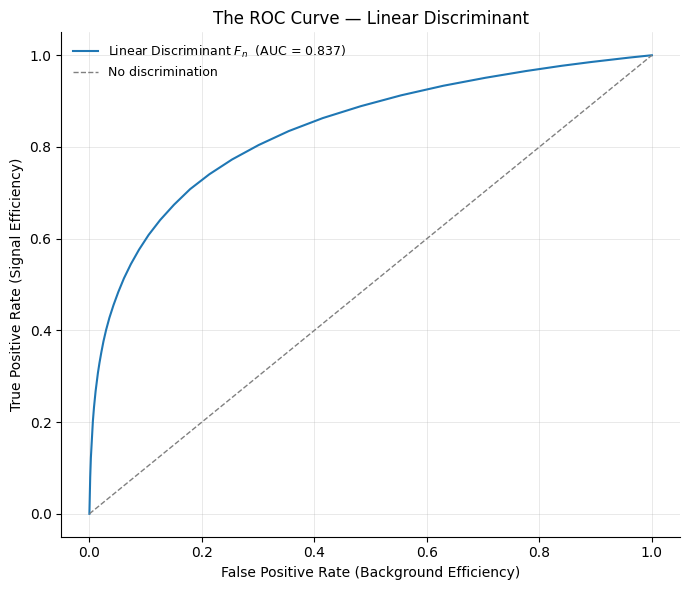

In [45]:
# Part 3

# Draw the ROC curve for the linear discriminant output F_n.
#
# F_n is a single score per event so we pass it directly into plot_roc_curves
# from 7.2 — no cut strategy lookup needed since the discriminant output
# is always treated as a simple x > x_c threshold

plot_roc_curves(
    var_labels=["Linear Discriminant $F_n$"],
    sig_arrays=[output_s],
    bkg_arrays=[output_b],
    title="The ROC Curve — Linear Discriminant"
)

In [46]:
# Part 4

# Findinng the maximum significance achievable with the linear discriminant for each of the four scenarios from Exercise 5.
#
# Since F_n combines all variables into one score we expect higher significance here than any single variable achieved
# in ex5 p3  - if not, the variables are too correlated for the discriminant to gain much by combining them.

# Sweep x_c over the full range of both signal and background output scores
xc_vals = np.linspace(
    min(output_s.min(), output_b.min()),
    max(output_s.max(), output_b.max()),
    N_POINTS
)

# TPR and FPR using searchsorted — same x > x_c logic as ex7 part 2
tpr_ld = 1.0 - np.searchsorted(np.sort(output_s), xc_vals, side="left") / len(output_s)
fpr_ld = 1.0 - np.searchsorted(np.sort(output_b), xc_vals, side="left") / len(output_b)

# given scenarios
scenarios = [
    (10,    100),
    (100,   1000),
    (1000,  10000),
    (10000, 100000),
]

rows = []
for (n_s, n_b) in scenarios:
    # Scale efficiencies by expected counts
    Ns_prime = tpr_ld * n_s
    Nb_prime = fpr_ld * n_b

    # Compute significance across the sweep, guarding against zero denominator
    denom = np.sqrt(Ns_prime + Nb_prime)
    with np.errstate(invalid="ignore", divide="ignore"):
        sig = np.where(denom > 0, Ns_prime / denom, 0.0)

    # Extract the peak significance and the values at that point
    best_idx = np.argmax(sig)
    best_xc  = xc_vals[best_idx]
    best_sig = sig[best_idx]
    best_tpr = tpr_ld[best_idx]
    best_fpr = fpr_ld[best_idx]

    rows.append([n_s, n_b, f"{best_tpr:.4f}", f"{best_fpr:.4f}",
                 f"{best_xc:.4f}", f"{best_sig:.3f}"])
# Display as HTML table — sigma values should scale with sqrt(N_S),
# and should be visibly higher than the best single-variable results from ex5p3
headers = ["N_S", "N_B", "TPR", "FPR", "Optimal x_c", "Max σ"]
display(HTML(tabulate(rows, headers=headers, tablefmt="html")))

N_S,N_B,TPR,FPR,Optimal x_c,Max σ
10,100,0.4837,0.0514,0.5948,1.532
100,1000,0.4837,0.0514,0.5948,4.843
1000,10000,0.4837,0.0514,0.5948,15.316
10000,100000,0.4837,0.0514,0.5948,48.432


### Finished - 4/3/2026